# DETEKCIA ÚMRTNOSTI V SÚVISLOSTI S OCHORENÍM COVID-19

In [1]:
pip install shap==0.44.1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from tabulate import tabulate
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical
import lightgbm as lgb
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
import shap
from sklearn.model_selection import GridSearchCV, train_test_split

import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix


%matplotlib inline


In [3]:
data = pd.read_excel("data_target_Death.xlsx")

data

,Derivation cohort,LOS,Severity,Black,White,Asian,Latino,MI,PVD,CHF,...,Sodium,Glucose,AST,ALT,WBC,Lympho,Ferritin,CrctProtein,Troponin,Death
0,1,1,3,0,0,0,0,0,0,0,...,135.000000,112.000000,26.000000,14.000000,5.600000,1.400000,0.00000,0.499900,0.010000,0
1,1,2,7,0,1,0,0,0,1,0,...,137.000000,265.000000,85.000000,32.000000,12.200000,0.300000,885.00000,14.900000,1.200000,1
2,1,2,7,0,1,0,0,0,1,1,...,140.000000,121.000000,32.000000,18.000000,6.100000,0.500000,629.00000,33.900000,0.025227,1
3,1,15,9,1,0,0,0,1,0,0,...,132.000000,182.277563,44.000000,17.000000,3.700000,0.500000,816.00000,18.400000,0.050000,0
4,1,9,7,1,0,0,0,0,0,0,...,149.000000,179.999111,38.000000,28.000000,5.700000,1.400000,1691.00000,11.600000,0.010000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4706,0,4,4,0,0,1,0,0,0,0,...,139.000000,97.000000,23.000000,24.000000,10.300000,1.000000,295.00000,1.800000,0.010000,0
4707,0,2,2,0,0,0,1,0,1,0,...,136.000000,163.719002,40.000000,30.000000,4.100000,1.200000,1165.00000,3.100000,0.010000,0
4708,0,5,1,0,0,0,0,0,1,0,...,136.000000,153.000000,26.000000,16.000000,7.400000,1.000000,239.00000,0.499900,0.000000,0
4709,0,4,3,1,0,0,0,0,1,0,...,137.000000,131.000000,31.000000,33.000000,7.600000,1.800000,1185.00000,8.600000,0.010000,0


In [4]:
# Renaming columns
data = data.rename(columns={
    'LOS': 'Length_of_stay',
    'MI': 'Myocardial_infarction',
    'PVD': 'Per_vascular_dis',
    'CHF': 'Cong_heart_failure',
    'CVD': 'Cardiovascular_dis',
    'DEMENT': 'Dementia',
    'COPD': 'Chronic_obst_pulm_dis',
    'DM Complicated': 'Diabetes_mel_complicated',
    'DM Simple': 'Diabetes_mel_simple',
    'Renal Disease': 'Renal_dis',
    'All CNS': 'All_CNS',
    'Pure CNS': 'Pure_CNS',
    'OldOtherNeuro': 'Other_neuro_dis',
    'OtherBrnLsn': 'Other_brain_lesions',
    'Age.1': 'Age_number',
    'AgeScore': 'Age_category',
    'OsSats': 'Oxygen_sat',
    'Temp': 'Temperature',
    'MAP': 'Mean_art_press',
    'Plts': 'Platelets',
    'INR': 'Inter_norm_ratio',
    'BUN': 'Blood_urea_nitr',
    'WBC': 'White_blood_cells',
    'CrctProtein': 'CRP'
})


In [5]:
original_data = data.copy()
data_copy = data.copy()

In [6]:
data.columns

Index(['Derivation cohort', 'Length_of_stay', 'Severity', 'Black', 'White',
       'Asian', 'Latino', 'Myocardial_infarction', 'Per_vascular_dis',
       'Cong_heart_failure', 'Cardiovascular_dis', 'Dementia',
       'Chronic_obst_pulm_dis', 'Diabetes_mel_complicated',
       'Diabetes_mel_simple', 'Renal_dis', 'All_CNS', 'Pure_CNS', 'Stroke',
       'Seizure', 'OldSyncope', 'Other_neuro_dis', 'Other_brain_lesions',
       'Age_number', 'Age_category', 'Oxygen_sat', 'Temperature',
       'Mean_art_press', 'Ddimer', 'Platelets', 'PltsScore',
       'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'CrtnScore',
       'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho',
       'Ferritin', 'CRP', 'Troponin', 'Death'],
      dtype='object')

In [7]:
filtered_data = data[data['Death'] == 1]

# Calculate the percentage of 1 values in the 'PVD' column
percentage = (filtered_data['Per_vascular_dis'] == 1).mean() * 100

print(f"Percentage of values equal to 1 in the 'PVD' column: {percentage:.2f}%")

Percentage of values equal to 1 in the 'PVD' column: 11.76%


In [8]:
filtered_data = data[data['Death'] == 0]

# Calculate the percentage of 1 values in the 'PVD' column
percentage = (filtered_data['Per_vascular_dis'] == 1).mean() * 100

print(f"Percentage of values equal to 1 in the 'PVD' column: {percentage:.2f}%")

Percentage of values equal to 1 in the 'PVD' column: 19.03%


<Axes: title={'center': 'Deaths'}, xlabel='Death', ylabel='count'>

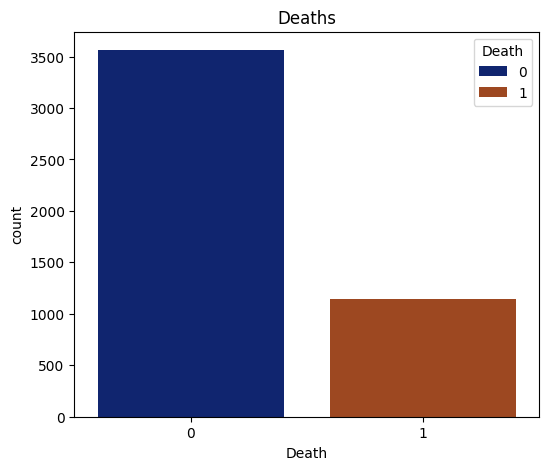

In [9]:
plt.figure(figsize=(6,5))
plt.title('Deaths')
sns.countplot(x='Death', data=data, hue="Death", palette="dark")

In [10]:
data["Death"].value_counts()

Death
0    3563
1    1148
Name: count, dtype: int64

<Axes: title={'center': 'Deaths by Severity distribution'}, xlabel='Severity', ylabel='Count'>

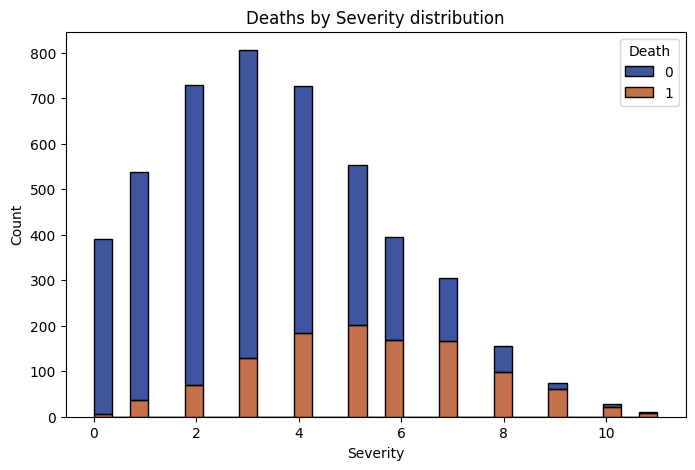

In [11]:
plt.figure(figsize=(8,5))
plt.title('Deaths by Severity distribution')
sns.histplot(x='Severity', hue='Death',multiple="stack", data=data, palette="dark")

Pravdepodobnosť úmrtia pre jednotlivé kategórie závažnosti

<Axes: title={'center': 'Deaths by Severity - probability distribution'}, xlabel='Severity', ylabel='Count'>

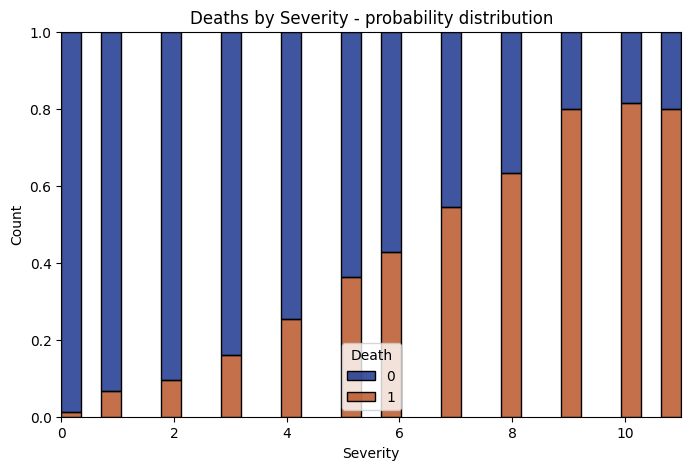

In [12]:
plt.figure(figsize=(8,5))
plt.title('Deaths by Severity - probability distribution')
sns.histplot(x='Severity', hue='Death',multiple="fill", data=data, palette="dark")

<Axes: title={'center': 'Ddimer and Death'}, xlabel='Ddimer', ylabel='Count'>

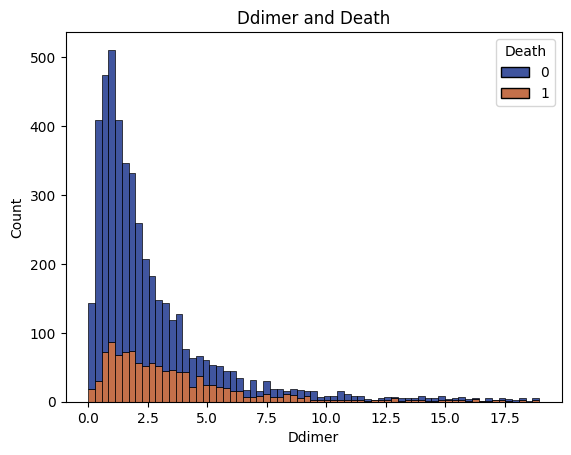

In [13]:
plt.title('Ddimer and Death')
sns.histplot(x="Ddimer", hue="Death",multiple="stack",  palette="dark",data=data)

<Axes: xlabel='Death', ylabel='Ddimer'>

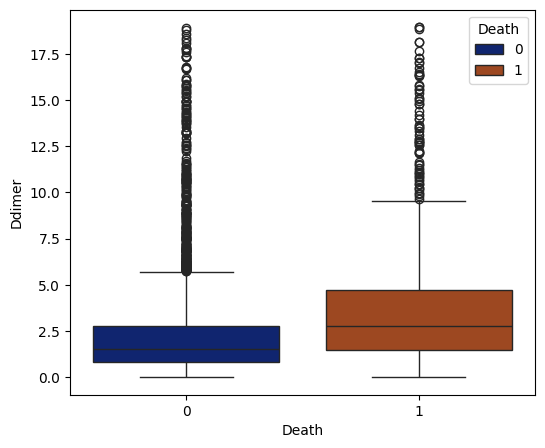

In [14]:
plt.figure(figsize=(6,5))
plt.title('')
sns.boxplot(x="Death", y="Ddimer", data=data, hue="Death",  palette="dark")

<Axes: xlabel='Death', ylabel='CRP'>

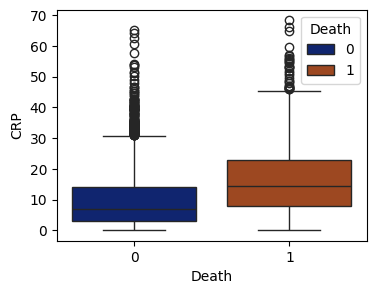

In [15]:
plt.figure(figsize=(4,3))
sns.boxplot(x='Death', y='CRP', data=data,   palette="dark",hue="Death")

<Axes: xlabel='Death', ylabel='Length_of_stay'>

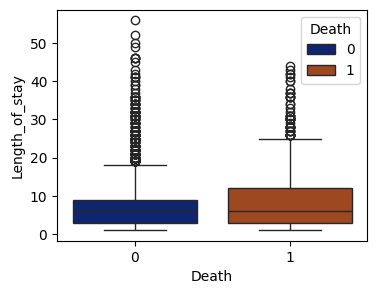

In [16]:
plt.figure(figsize=(4,3))
sns.boxplot(x='Death', y='Length_of_stay',  palette="dark",data=data, hue="Death")

# FEATURE IMPORTANCE

In [17]:
numeric_features = data.columns[data.nunique() > 10]
numeric_features = numeric_features.drop("Severity")

print("Columnns that contain more than 10 values:\n", numeric_features)
print("Number of nuemrical features:", numeric_features.size)

Columnns that contain more than 10 values:
 Index(['Length_of_stay', 'Age_number', 'Oxygen_sat', 'Temperature',
       'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio',
       'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT',
       'White_blood_cells', 'Lympho', 'Ferritin', 'CRP', 'Troponin'],
      dtype='object')
Number of nuemrical features: 19


In [18]:
categorical_features = data.columns[data.nunique() <=4]

print("Columnns that contain less than 10 values:\n", categorical_features)
print("Number of categorical features:", categorical_features.size)

Columnns that contain less than 10 values:
 Index(['Derivation cohort', 'Black', 'White', 'Asian', 'Latino',
       'Myocardial_infarction', 'Per_vascular_dis', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_category', 'PltsScore',
       'CrtnScore', 'Death'],
      dtype='object')
Number of categorical features: 25


### CHI - square test for categorical input and categorical output

In [19]:
data_copy["Per_vascular_dis"] = data_copy["Per_vascular_dis"].replace(2, 1)


Chi-Squared Test Results:
Feature	P-Value
Age_category	2.1703945093169352e-91
CrtnScore	3.748625005527011e-67
All_CNS	1.3717002247858003e-09
Per_vascular_dis	6.085270273659997e-09
Pure_CNS	3.980010269694054e-08
PltsScore	9.0682597734465e-06
Stroke	2.224134008461991e-05
Renal_dis	0.009781291316445753
Derivation cohort	0.022965061711313815
Chronic_obst_pulm_dis	0.027317159528824877
White	0.027392527974317557




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



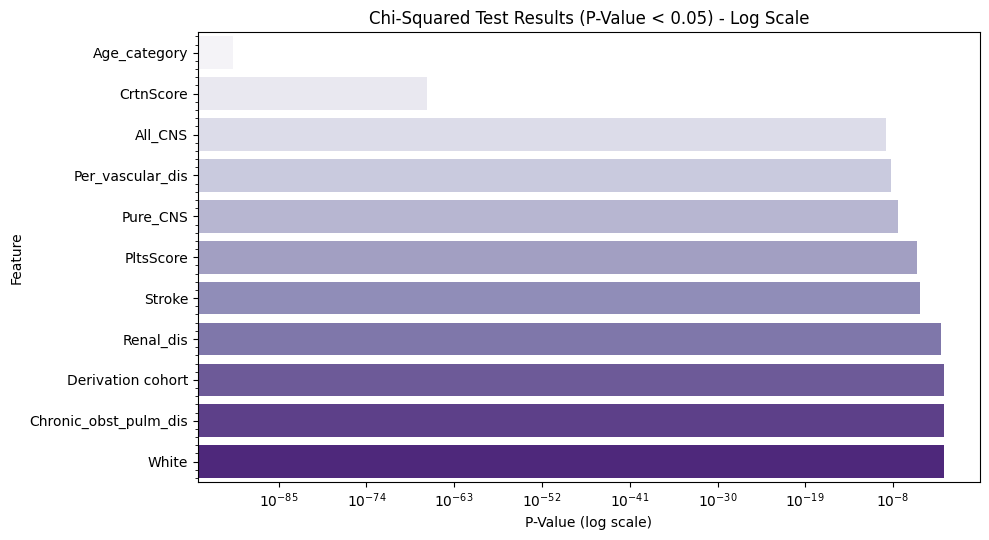

In [20]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame(data)

# Encode these categorical features
le = LabelEncoder()
for column in categorical_features:
    # Make sure to encode only if the column is not the target variable 'Death'
    if df[column].dtype == 'object' or column in categorical_features:
        df[column] = le.fit_transform(df[column].astype(str))

features_to_test = [col for col in categorical_features if col != 'Death']

# Perform the chi-squared test
chi2_stat, p_values = chi2(df[features_to_test], df['Death'])

# Correctly display p-values in ascending order and filter for p < 0.05
sorted_features_p_values = sorted(zip(features_to_test, p_values), key=lambda x: x[1])
print("\nChi-Squared Test Results:\nFeature\tP-Value")
for feature, p_value in sorted_features_p_values:
    if p_value < 0.05:
        print(f"{feature}\t{p_value}")

# Filter for p-values < 0.05 and convert to DataFrame for easier handling
filtered_p_values = [(feature, p_value) for feature, p_value in sorted_features_p_values if p_value < 0.05]
filtered_df = pd.DataFrame(filtered_p_values, columns=['Feature', 'P-Value'])

# Adjust the visualization with a log scale
plt.figure(figsize=(10, len(filtered_p_values) * 0.5))
sns.barplot(x='P-Value', y='Feature', data=filtered_df, palette='Purples')

# Set the x-axis to log scale to better visualize values close to 0
plt.xscale('log')

# Adding minor ticks to improve readability of the log scale
plt.minorticks_on()
plt.tick_params(axis='x', which='minor', bottom=False)

plt.xlabel('P-Value (log scale)')
plt.ylabel('Feature')
plt.title('Chi-Squared Test Results (P-Value < 0.05) - Log Scale')
plt.tight_layout()
plt.show()


# Normalizácia dát kvôli ANOVE a ttestu - DATA COPY

### Výber numerických atribútov

In [21]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['Severity', 'CrtnScore','PltsScore','Age_category', "Per_vascular_dis"]) #drop items that show categories, scores, etc.

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Length_of_stay', 'Age_number', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'Ferritin', 'CRP', 'Troponin']
19


## 2. Log transformation - data copy

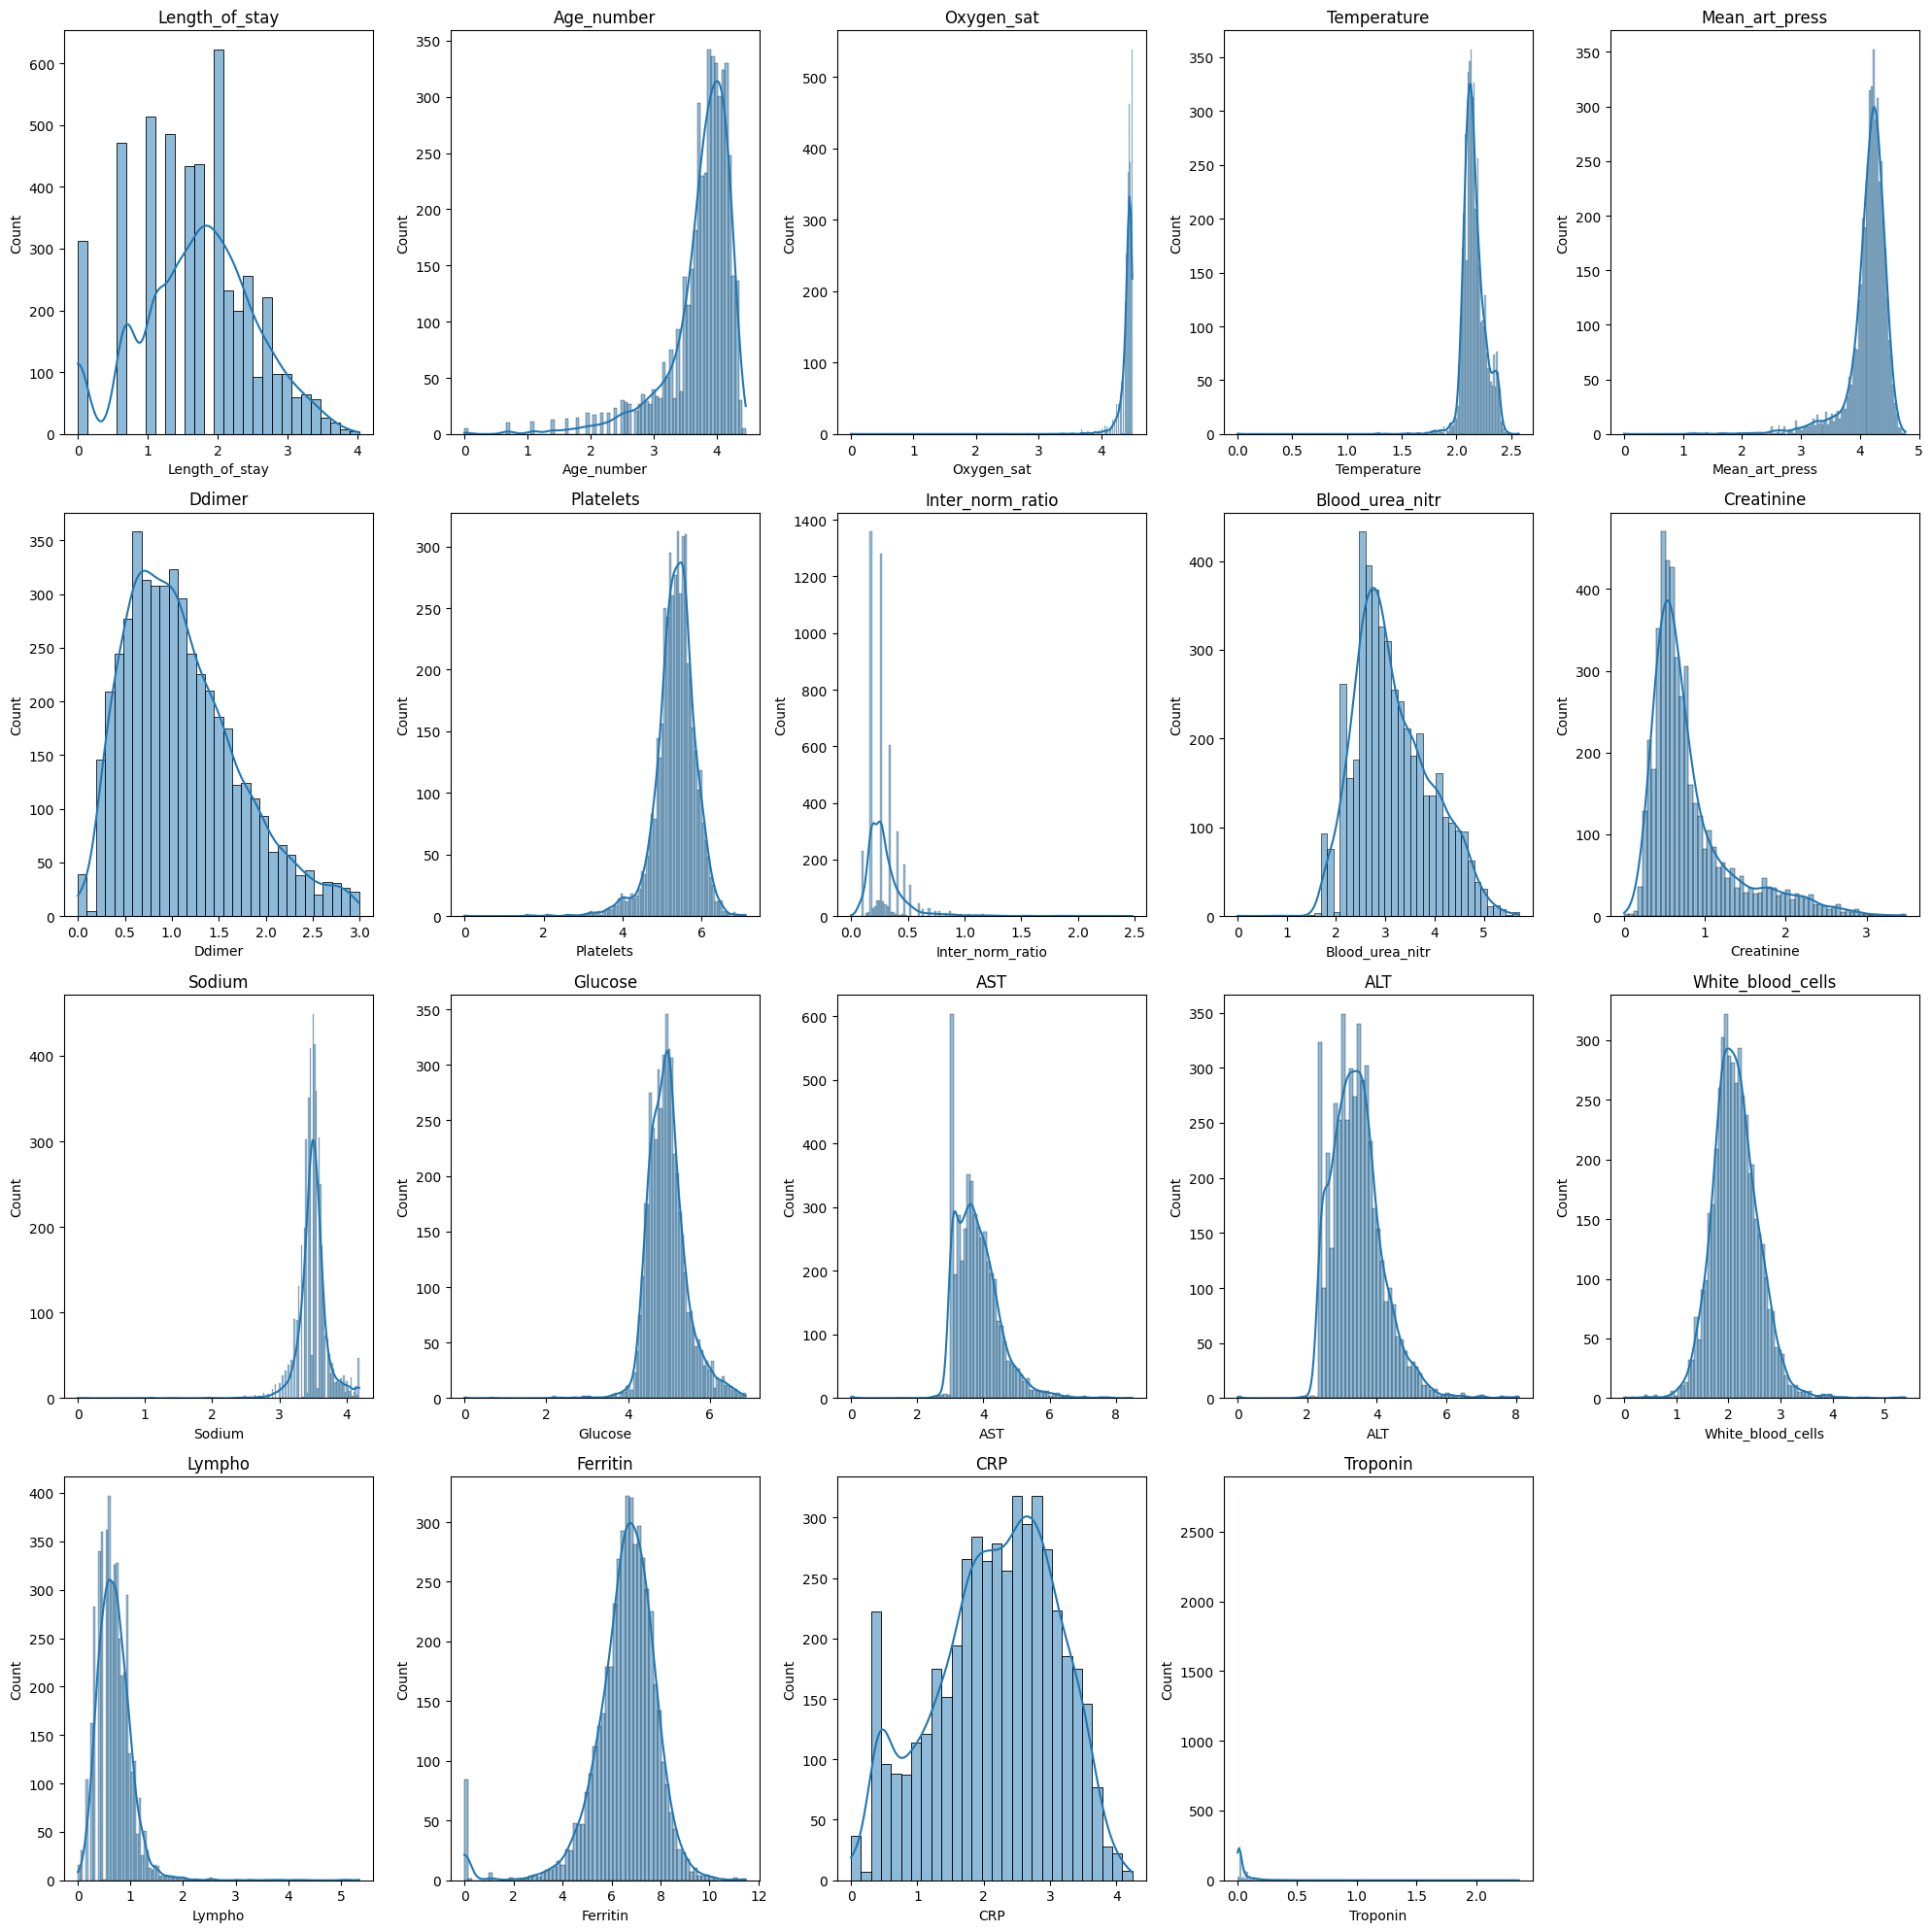

In [22]:
data_copy[selectedColumns] = data_copy[selectedColumns] + 1 - data_copy[selectedColumns].min()

# Apply log transformation
data_copy[selectedColumns] = np.log(data_copy[selectedColumns])

# Set up the figure with subplots (5 plots in a row)
num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data_copy[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## ANOVA pre vplyv numerických atribútov na kategorický

ANOVA Test Results:
Feature		P-Value
Mean_art_press		1.3548968289450827e-171
Blood_urea_nitr		1.1450253067760662e-94
CRP		8.999299241579247e-85
Age_number		5.925426078602493e-66
Ddimer		1.0681122416682899e-60
Creatinine		2.5402488575879336e-47
Ferritin		1.378992699542846e-37
Oxygen_sat		2.380998019687397e-35
Troponin		4.354690622766595e-31
AST		7.326444887320783e-30
Inter_norm_ratio		3.5783293687467e-25
Glucose		1.7328515307409757e-12
Sodium		8.672823981745378e-12
Lympho		2.1512331496708042e-10
White_blood_cells		2.8001577390836073e-10
Length_of_stay		3.867593842229331e-06
Platelets		6.069832766074526e-06
ALT		0.02237547533471154
Temperature		0.7139882872796813


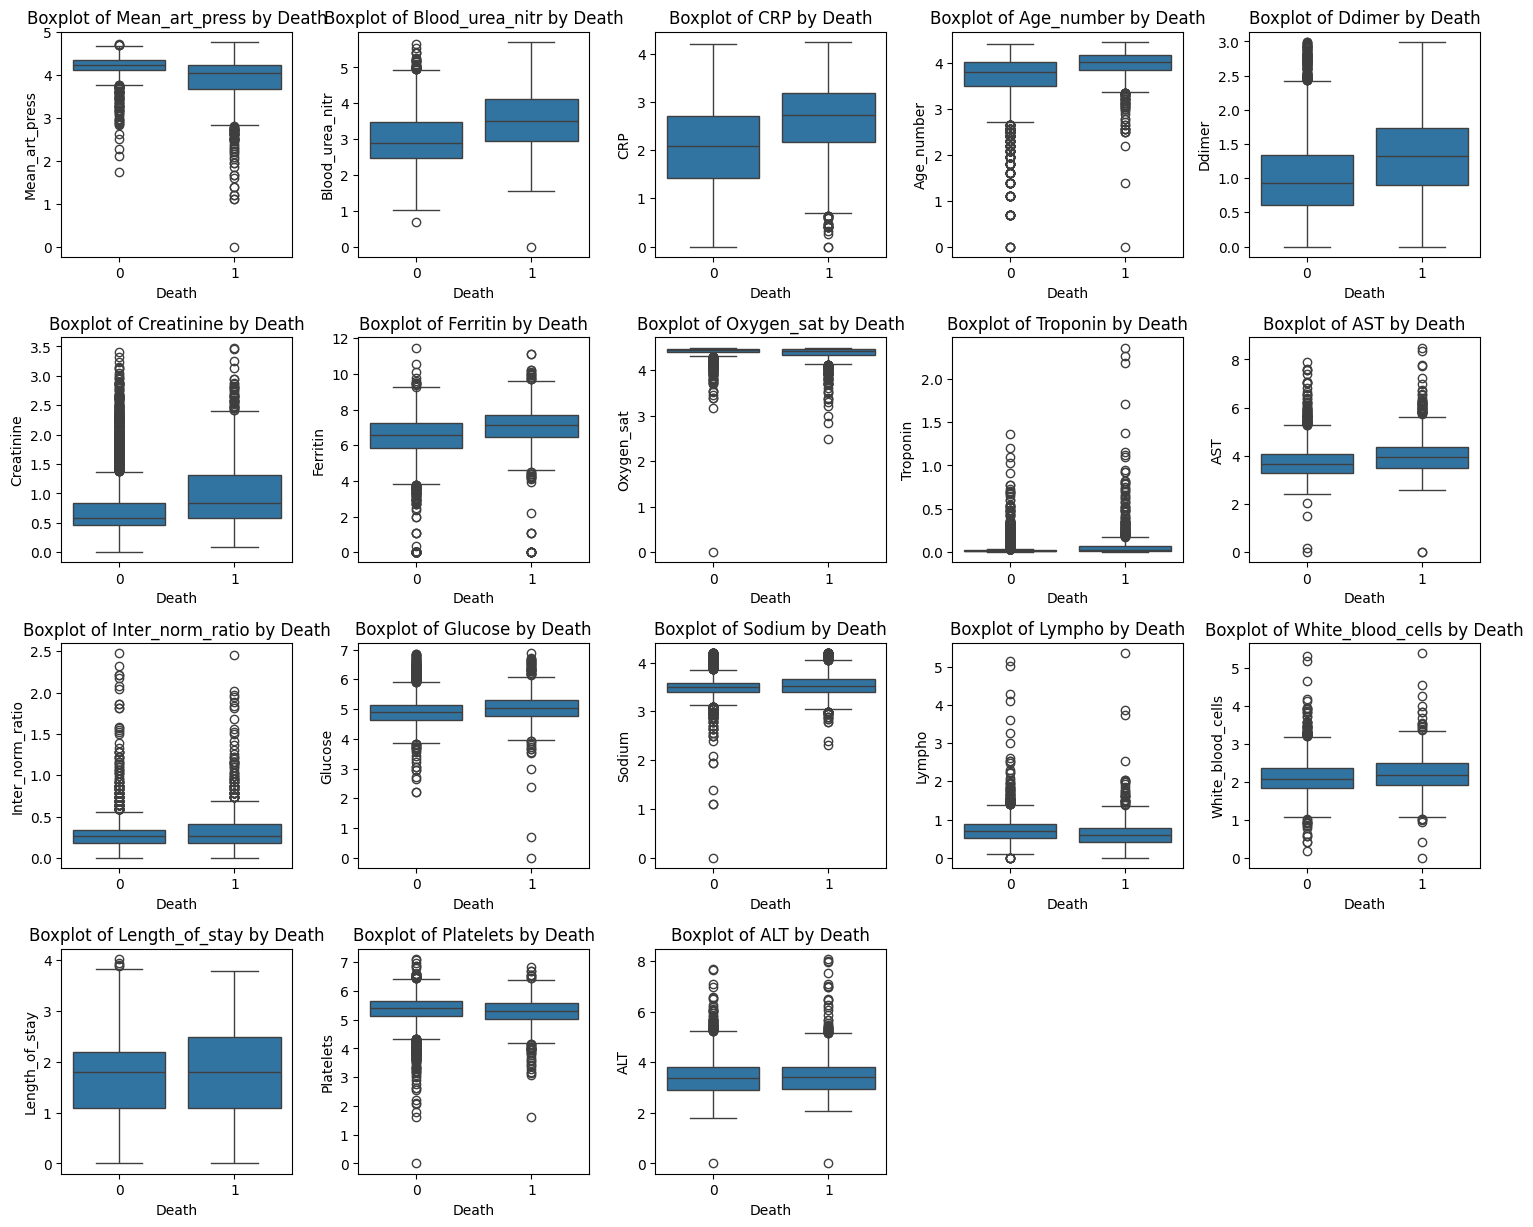

In [23]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

df = pd.DataFrame(data_copy)

# Perform ANOVA test for numeric features
f_stat, p_values_anova = f_classif(df[numeric_features], df['Death'])

# Display p-values in ascending order
print("ANOVA Test Results:")
print("Feature\t\tP-Value")
sorted_p_values_anova = sorted(zip(numeric_features, p_values_anova), key=lambda x: x[1])
for feature, p_value_anova in sorted_p_values_anova:
    print(f"{feature}\t\t{p_value_anova}")

# Visualize boxplots for significant features
significant_features = [feature for feature, p_value in sorted_p_values_anova if p_value < 0.05]


plt.figure(figsize=(15, 15))
for i, feature in enumerate(significant_features, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(x='Death', y=feature, data=df)
    plt.title(f'Boxplot of {feature} by Death')
    plt.xlabel('Death')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()


### Vizualizácia top 8 atribútov podľa ANOVA

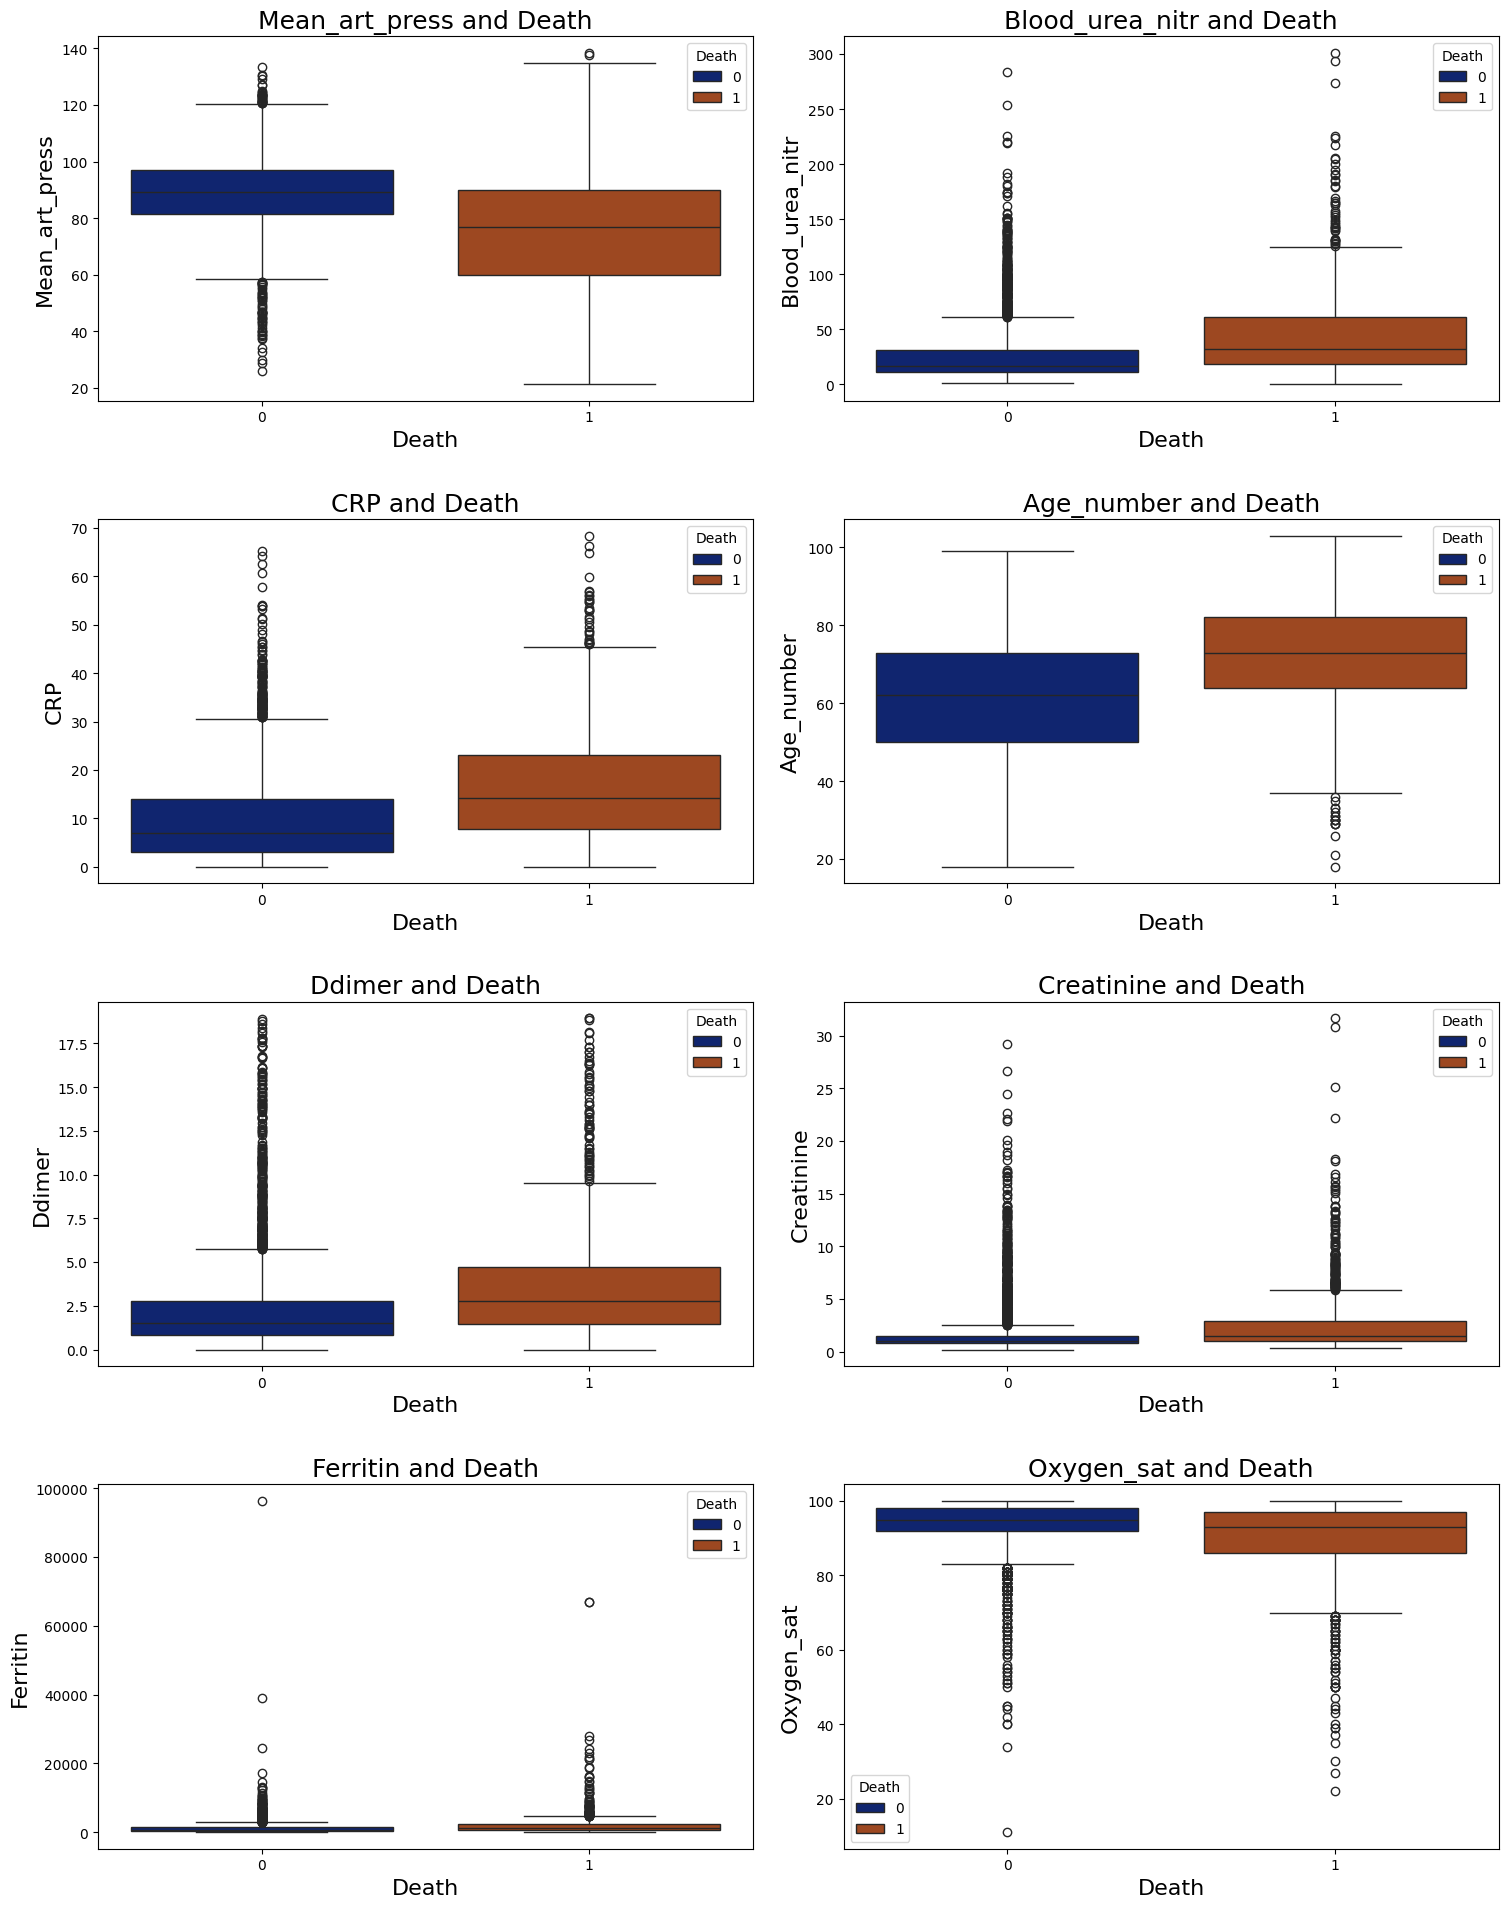

In [24]:
top_8_features = significant_features[:8]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))

axes = axes.flatten()

# Iterate over the top 8 significant features and create boxplots
for i, feature in enumerate(top_8_features):
    sns.boxplot(x='Death', y=feature, data=original_data, hue="Death",palette="dark",  ax=axes[i])
    axes[i].set_title(f'{feature} and Death', fontsize=18)
    axes[i].set_xlabel('Death', fontsize=16)
    axes[i].set_ylabel(feature, fontsize=16)

plt.tight_layout(pad=4.0, h_pad=3.0, w_pad=2.0)

plt.show()


## T-test

T-test Results:
Feature		P-Value
Mean_art_press		1.3548968283161362e-171
Blood_urea_nitr		1.1450253067588597e-94
CRP		8.999299241610621e-85
Age_number		5.925426078873513e-66
Ddimer		1.0681122416703123e-60
Creatinine		2.540248857599088e-47
Ferritin		1.3789926995520605e-37
Oxygen_sat		2.3809980220673824e-35
Troponin		4.354690622773724e-31
AST		7.326444887330724e-30
Inter_norm_ratio		3.578329368775832e-25
Glucose		1.7328515306727254e-12
Sodium		8.672823980692063e-12
Lympho		2.1512331496745136e-10
White_blood_cells		2.8001577390606913e-10
Length_of_stay		3.867593842239948e-06
Platelets		6.069832766059341e-06
ALT		0.022375475334761644
Temperature		0.7139882873452564


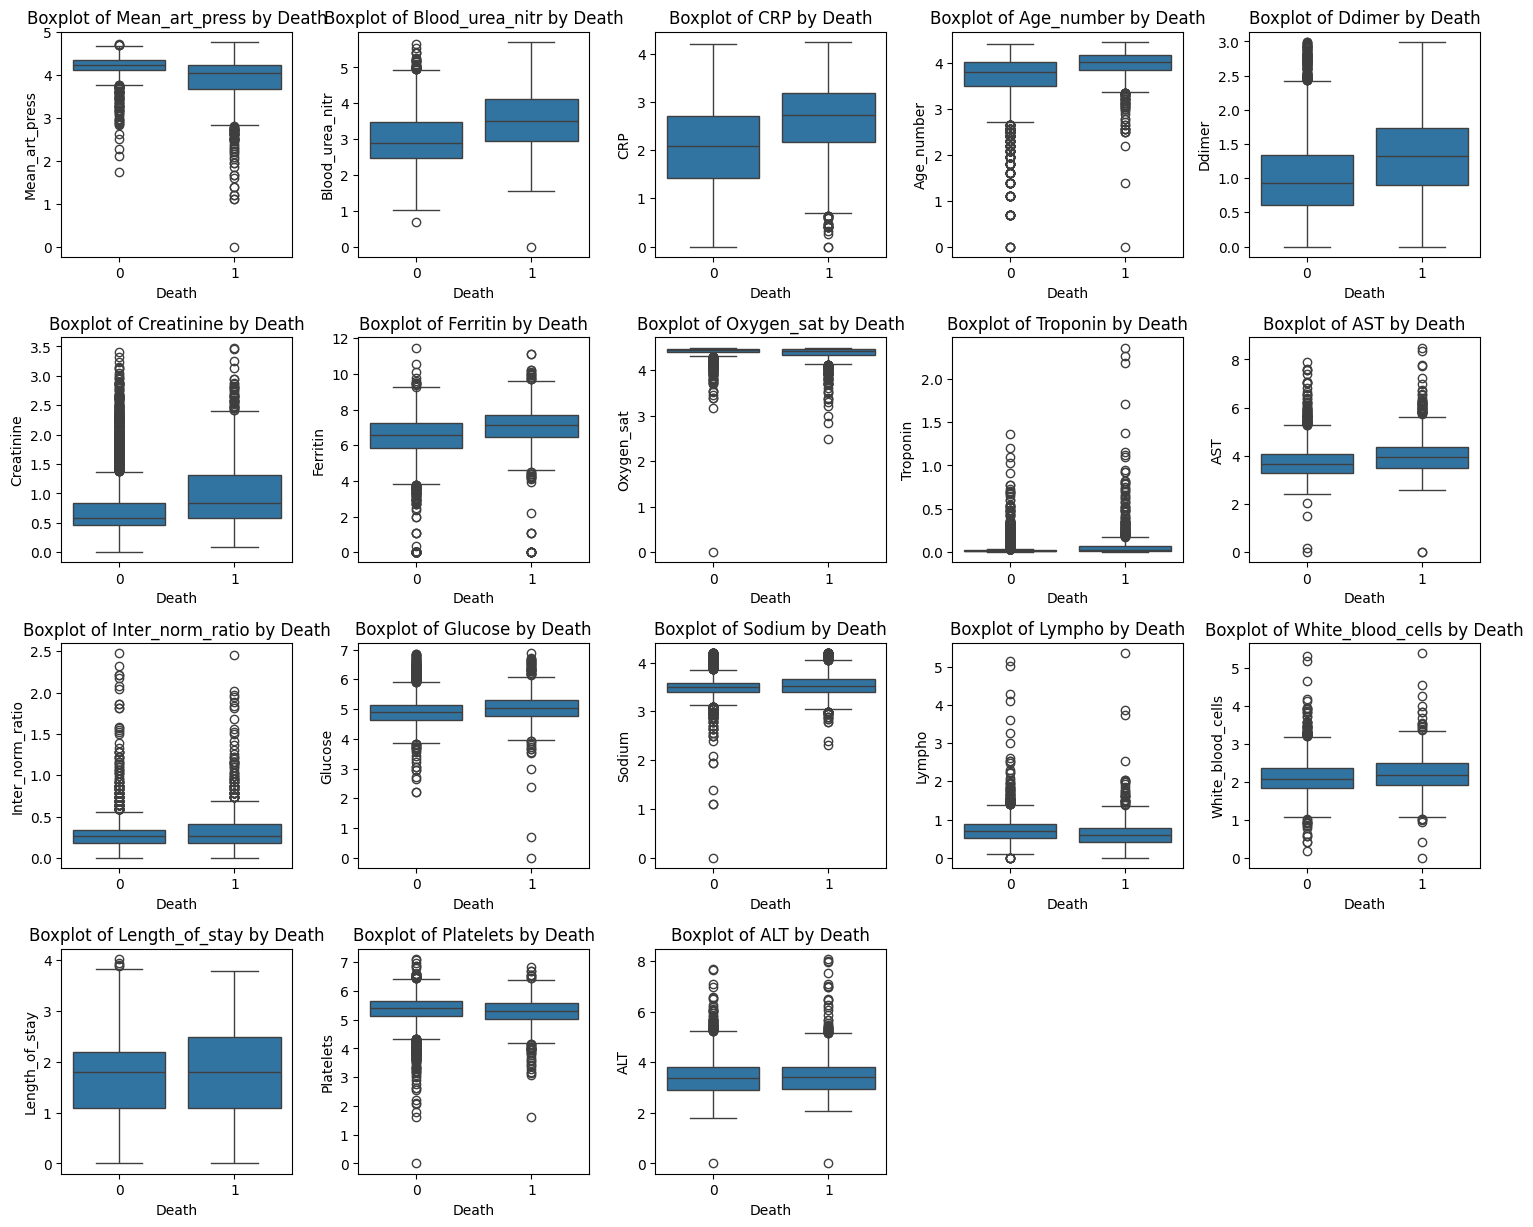

In [25]:
from scipy.stats import ttest_ind

df = pd.DataFrame(data_copy)

# Perform t-test for numeric features
t_test_results = []
for feature in numeric_features:
    group1 = df[df['Death'] == 0][feature]
    group2 = df[df['Death'] == 1][feature]
    t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')
    t_test_results.append((feature, p_value))

# Display p-values in ascending order
print("T-test Results:")
print("Feature\t\tP-Value")
sorted_t_test_results = sorted(t_test_results, key=lambda x: x[1])
for feature, p_value in sorted_t_test_results:
    print(f"{feature}\t\t{p_value}")

# Visualize boxplots for significant features
significant_features = [feature for feature, p_value in sorted_t_test_results if p_value < 0.05]

# Create subplots for boxplots
plt.figure(figsize=(15, 15))
for i, feature in enumerate(significant_features, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(x='Death', y=feature, data=df)
    plt.title(f'Boxplot of {feature} by Death')
    plt.xlabel('Death')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()


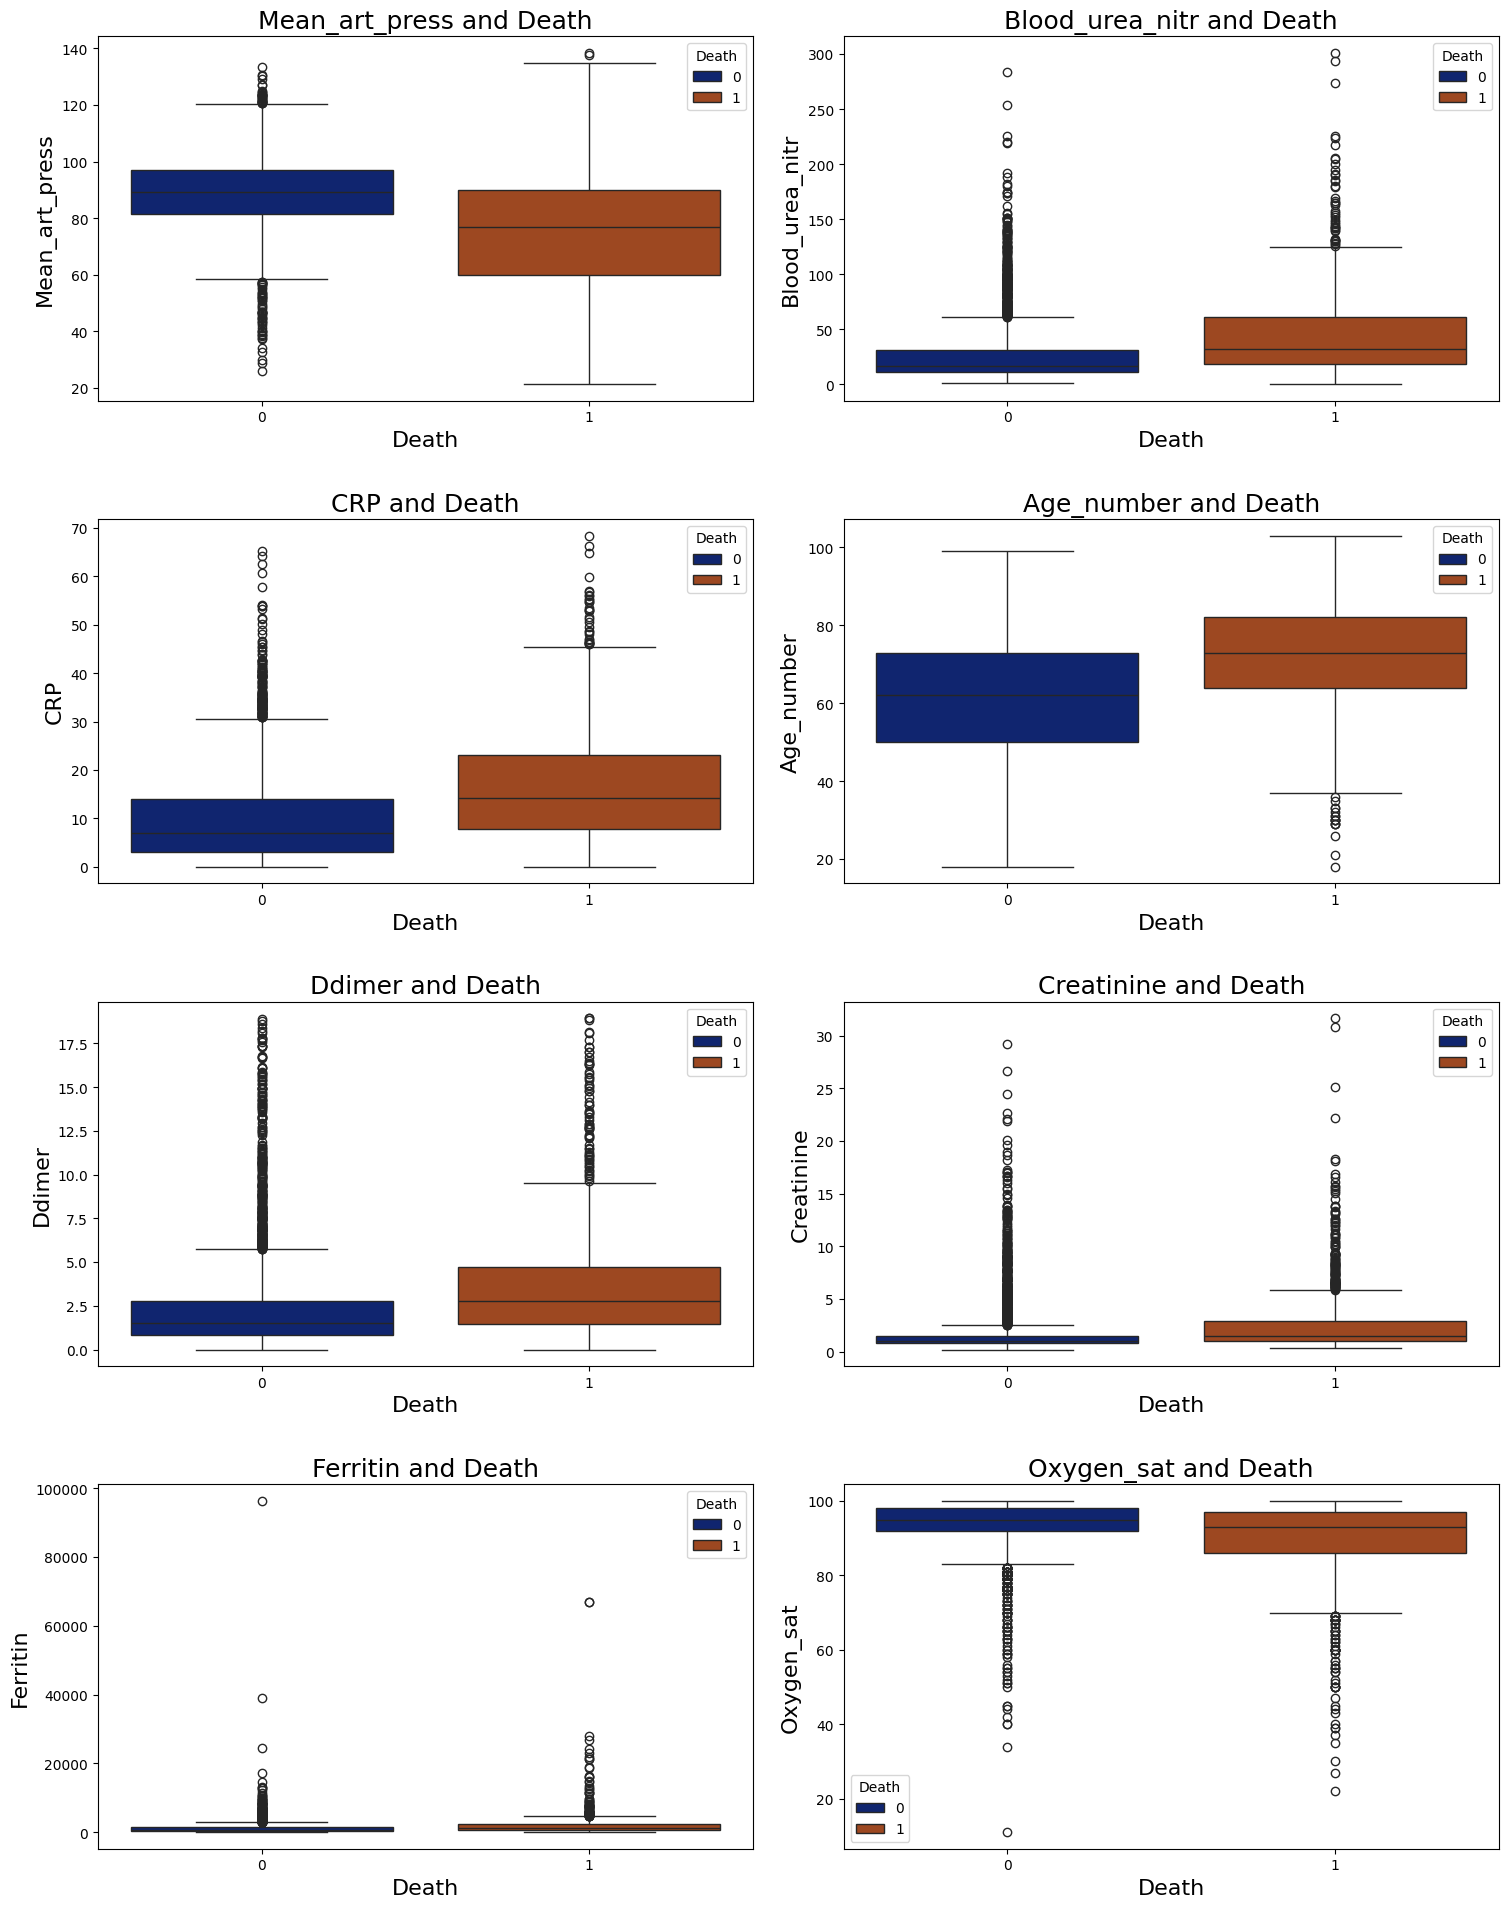

In [26]:
top_8_features = significant_features[:8]

# Setup the matplotlib figure and axes for a 4x2 subplot layout
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))

axes = axes.flatten()

for i, feature in enumerate(top_8_features):
    sns.boxplot(x='Death', y=feature, data=original_data, hue="Death", palette="dark",  ax=axes[i])
    axes[i].set_title(f'{feature} and Death', fontsize=18)
    axes[i].set_xlabel('Death', fontsize=16)
    axes[i].set_ylabel(feature, fontsize=16)

plt.tight_layout(pad=4.0, h_pad=3.0, w_pad=2.0)

plt.show()




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



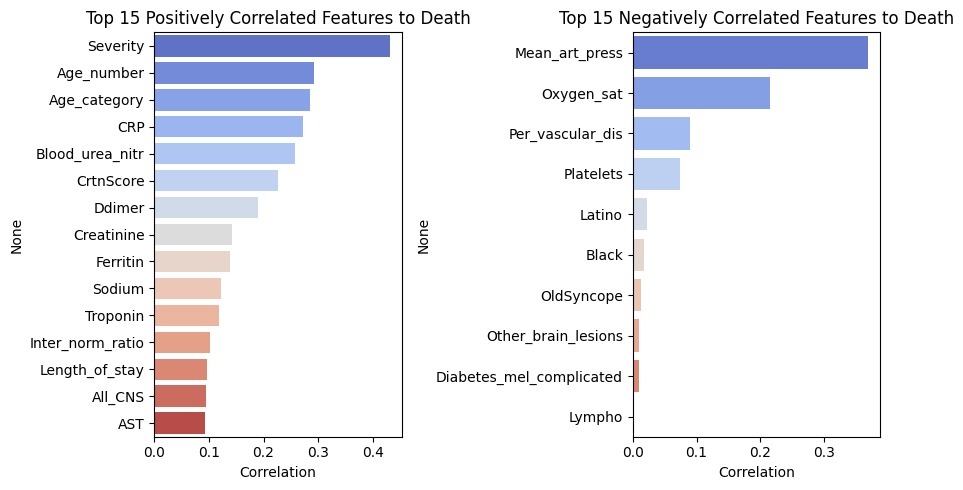

In [27]:
# Calculate the correlations between all features and 'Severity'
correlations = data.corr()['Death'].drop('Death')

# Split correlations into positive and negative
positive_correlations = correlations[correlations > 0]
negative_correlations = correlations[correlations < 0]

# Sort the correlations by their absolute values in descending order
positive_correlations_sorted = positive_correlations.sort_values(ascending=False)
negative_correlations_sorted = negative_correlations.abs().sort_values(ascending=False)

# Extract the top correlated features (both positively and negatively)
n_top_features = 15

# Plot the most positively correlated features
plt.figure(figsize=(9, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=positive_correlations_sorted.head(n_top_features), y=positive_correlations_sorted.head(n_top_features).index, palette='coolwarm')
plt.xlabel('Correlation')
plt.title(f'Top {n_top_features} Positively Correlated Features to Death')

# Plot the most negatively correlated features
plt.subplot(1, 2, 2)
sns.barplot(x=negative_correlations_sorted.head(n_top_features), y=negative_correlations_sorted.head(n_top_features).index, palette="coolwarm")
plt.xlabel('Correlation')
plt.title(f'Top {n_top_features} Negatively Correlated Features to Death')

plt.tight_layout()
plt.show()

## LASSO Regression

LASSO regresia pre binárny cieľový atribút

In [28]:
X = data_copy.drop(["Death"],axis=1)
y = data_copy["Death"]

Accuracy: 0.8144220572640509
              precision    recall  f1-score   support

           0       0.83      0.95      0.88       699
           1       0.74      0.44      0.55       244

    accuracy                           0.81       943
   macro avg       0.78      0.69      0.72       943
weighted avg       0.80      0.81      0.80       943



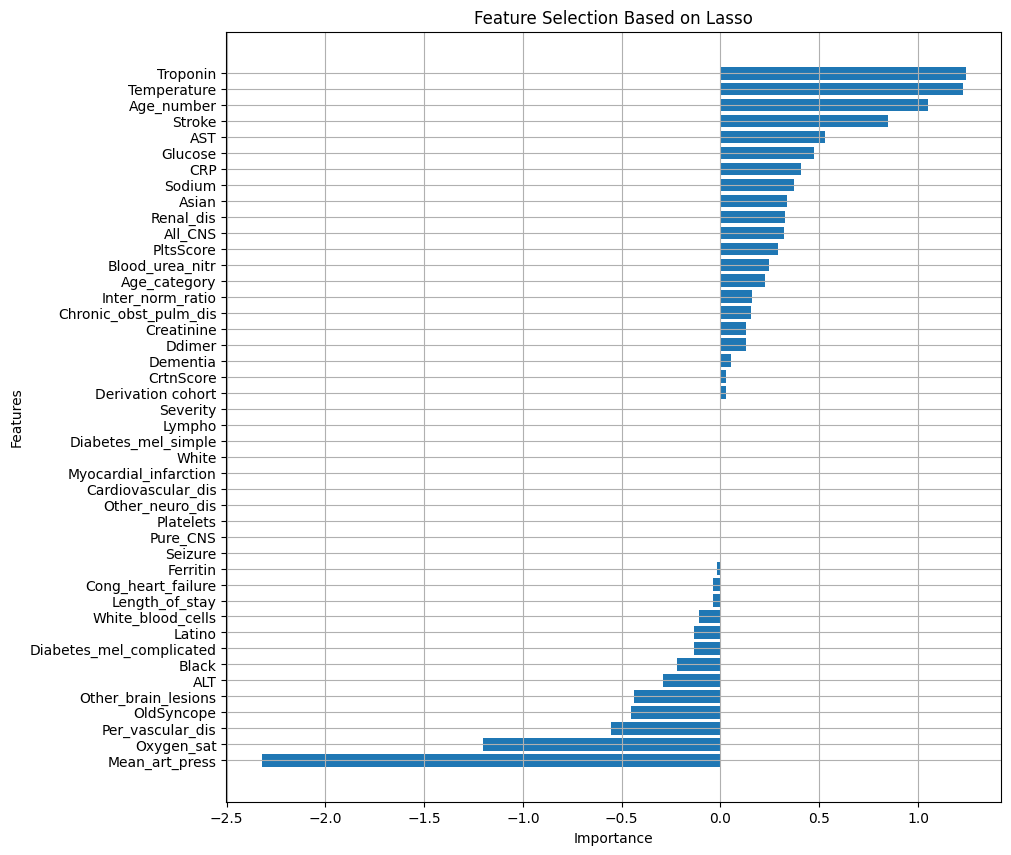

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create logistic regression model with L1 penalty
model = LogisticRegression(penalty='l1', solver='liblinear')

# Train the model
model.fit(X_train, y_train)

# Get the feature importance (coefficients) after training
feature_importance = model.coef_[0]

# Evaluate the model on the testing set
y_pred = model.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

# Classification report
print(classification_report(y_test, y_pred))

# Sort feature importance coefficients
sorted_indices = np.argsort(feature_importance)

# Get sorted feature names and importance values
sorted_features = np.array(X.columns)[sorted_indices]
sorted_importance = feature_importance[sorted_indices]

# Plotting
plt.figure(figsize=(10,10))
plt.barh(sorted_features, sorted_importance)
plt.grid(True)
plt.title("Feature Selection Based on Lasso")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


# Normalizácia pre modelovanie

### Výber numerických atribútov

In [30]:
#show only column names with more than 2 unique values, discarding all boolean ones.
cols = ((data.dtypes != 'object') & (data.nunique() > 2))
cols = cols.drop(['Severity', 'CrtnScore','PltsScore','Age_category', "Per_vascular_dis"]) #drop items that show categories, scores, etc.

selectedColumns = list(cols[cols].index)
print(selectedColumns)
print(len(selectedColumns))

['Length_of_stay', 'Age_number', 'Oxygen_sat', 'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets', 'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium', 'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'Ferritin', 'CRP', 'Troponin']
19


Numeric features distributions

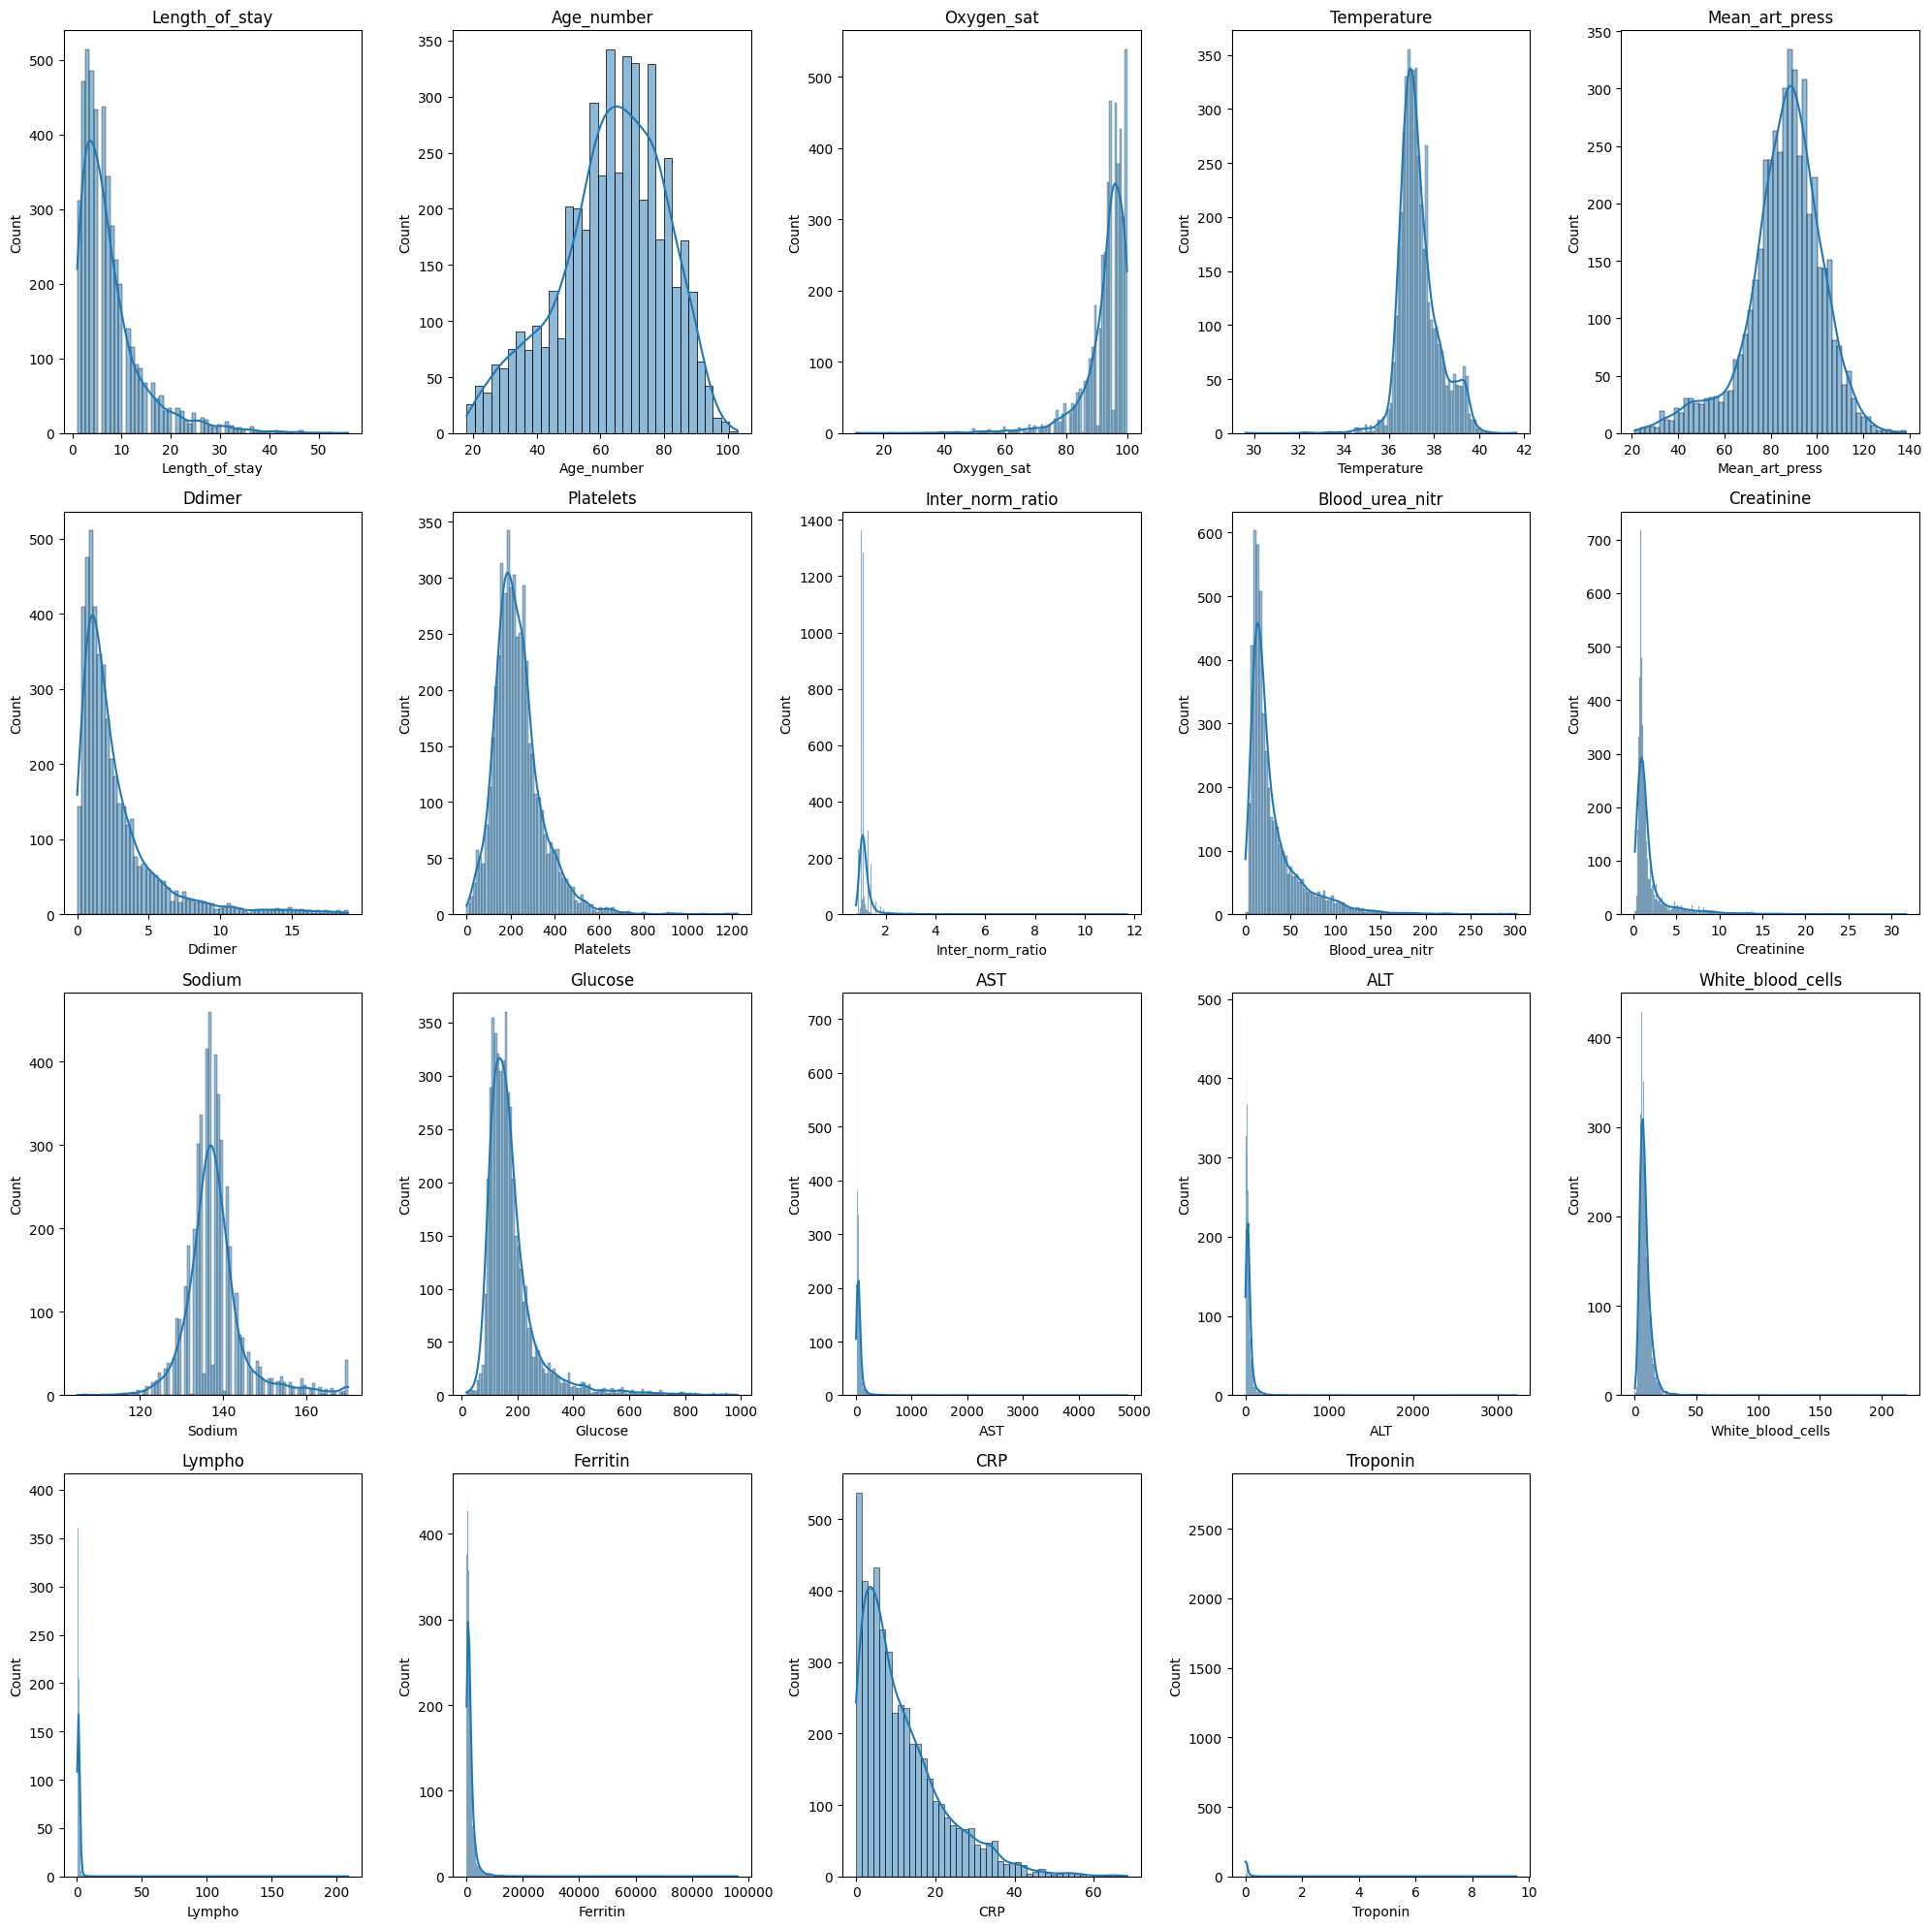

In [31]:
# Set up the figure with subplots (5 plots in a row)
num_plots_in_row = 5
num_rows = (len(selectedColumns) + num_plots_in_row - 1) // num_plots_in_row
fig, axes = plt.subplots(nrows=num_rows, ncols=num_plots_in_row, figsize=(20, 5 * num_rows))

axes = axes.flatten()

# Plot the distribution of each numeric column
for i, column in enumerate(selectedColumns):
    sns.histplot(data[column], kde=True, ax=axes[i])
    axes[i].set_title(column)

for j in range(len(selectedColumns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

MinMax normalizácia numerických atribútov

In [32]:
# Select the columns you want to normalize
columns_to_normalize = selectedColumns

# Create a new DataFrame for the columns to normalize
data_to_normalize = data[columns_to_normalize]

# Normalize using Min-Max scaling
min_max_scaler = MinMaxScaler()
data_to_normalize_minmax = min_max_scaler.fit_transform(data_to_normalize)

# Update the original DataFrame with the normalized values
data[columns_to_normalize] = data_to_normalize_minmax

data.head(5)

,Derivation cohort,Length_of_stay,Severity,Black,White,Asian,Latino,Myocardial_infarction,Per_vascular_dis,Cong_heart_failure,...,Sodium,Glucose,AST,ALT,White_blood_cells,Lympho,Ferritin,CRP,Troponin,Death
0,1,0.000000,3,0,0,0,0,0,0,0,...,0.461531,0.096907,0.005338,0.004337,0.024601,0.006220,0.000000,0.007308,0.001046,0
1,1,0.018182,7,0,1,0,0,0,1,0,...,0.492300,0.254639,0.017450,0.009913,0.054670,0.000957,0.009192,0.217836,0.125523,1
2,1,0.018182,7,0,1,0,0,0,1,1,...,0.538453,0.106186,0.006569,0.005576,0.026879,0.001914,0.006533,0.495614,0.002639,1
3,1,0.254545,9,1,0,0,0,1,0,0,...,0.415378,0.169358,0.009033,0.005266,0.015945,0.001914,0.008475,0.269006,0.005230,0
4,1,0.145455,7,1,0,0,0,0,0,0,...,0.676913,0.167009,0.007801,0.008674,0.025057,0.006220,0.017563,0.169591,0.001046,0


Vytvorenie pomocných "dummies" atribútov pre kategorické atribúty

In [33]:
# pandas get_dummies to create dummy variables for each categorical column
data = pd.get_dummies(data, columns=['CrtnScore','PltsScore','Age_category', "Per_vascular_dis"], prefix=[ 'CrtnScore','PltsScore','Age_category', "Per_vascular_dis"])

data.head(5)

,Derivation cohort,Length_of_stay,Severity,Black,White,Asian,Latino,Myocardial_infarction,Cong_heart_failure,Cardiovascular_dis,...,PltsScore_0,PltsScore_1,PltsScore_2,Age_category_0,Age_category_1,Age_category_2,Age_category_3,Per_vascular_dis_0,Per_vascular_dis_1,Per_vascular_dis_2
0,1,0.000000,3,0,0,0,0,0,0,0,...,True,False,False,False,False,False,True,True,False,False
1,1,0.018182,7,0,1,0,0,0,0,0,...,True,False,False,False,True,False,False,False,True,False
2,1,0.018182,7,0,1,0,0,0,1,1,...,False,True,False,False,False,False,True,False,True,False
3,1,0.254545,9,1,0,0,0,1,0,0,...,True,False,False,False,False,True,False,True,False,False
4,1,0.145455,7,1,0,0,0,0,0,0,...,False,True,False,False,False,True,False,True,False,False


In [34]:
data.columns

Index(['Derivation cohort', 'Length_of_stay', 'Severity', 'Black', 'White',
       'Asian', 'Latino', 'Myocardial_infarction', 'Cong_heart_failure',
       'Cardiovascular_dis', 'Dementia', 'Chronic_obst_pulm_dis',
       'Diabetes_mel_complicated', 'Diabetes_mel_simple', 'Renal_dis',
       'All_CNS', 'Pure_CNS', 'Stroke', 'Seizure', 'OldSyncope',
       'Other_neuro_dis', 'Other_brain_lesions', 'Age_number', 'Oxygen_sat',
       'Temperature', 'Mean_art_press', 'Ddimer', 'Platelets',
       'Inter_norm_ratio', 'Blood_urea_nitr', 'Creatinine', 'Sodium',
       'Glucose', 'AST', 'ALT', 'White_blood_cells', 'Lympho', 'Ferritin',
       'CRP', 'Troponin', 'Death', 'CrtnScore_0', 'CrtnScore_1', 'CrtnScore_2',
       'PltsScore_0', 'PltsScore_1', 'PltsScore_2', 'Age_category_0',
       'Age_category_1', 'Age_category_2', 'Age_category_3',
       'Per_vascular_dis_0', 'Per_vascular_dis_1', 'Per_vascular_dis_2'],
      dtype='object')

# PREDICTING DEATH CLASS WITH ALL FEATURES
##  = BINARY CLASSIFICATION

In [35]:
X = data.drop(columns=["Death","Severity"])
y = data["Death"]

In [36]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4711 entries, 0 to 4710
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Derivation cohort         4711 non-null   int64  
 1   Length_of_stay            4711 non-null   float64
 2   Black                     4711 non-null   int64  
 3   White                     4711 non-null   int64  
 4   Asian                     4711 non-null   int64  
 5   Latino                    4711 non-null   int64  
 6   Myocardial_infarction     4711 non-null   int64  
 7   Cong_heart_failure        4711 non-null   int64  
 8   Cardiovascular_dis        4711 non-null   int64  
 9   Dementia                  4711 non-null   int64  
 10  Chronic_obst_pulm_dis     4711 non-null   int64  
 11  Diabetes_mel_complicated  4711 non-null   int64  
 12  Diabetes_mel_simple       4711 non-null   int64  
 13  Renal_dis                 4711 non-null   int64  
 14  All_CNS 

In [37]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)

Train_x : (3768, 52)
Test_x : (943, 52)
Train_y : (3768,)
Test_y : (943,)


# Základné modely - Metriky ROC AUC, F-1 aj Accuracy

In [38]:
models = [
    ('RandomForest', RandomForestClassifier(n_estimators=100)),
    ('LGBM', LGBMClassifier()),
    ('XGB', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ('KNN', KNeighborsClassifier()),
    ('NaiveBayes', GaussianNB()),
    ('SVC', SVC(probability=True)),
    ('LogisticRegression', LogisticRegression(max_iter=1000)),
    ('MLP', MLPClassifier(max_iter=1000)),
]

scoring_metrics = ['accuracy', 'f1', 'roc_auc']
results = []
for name, model in models:
    row = [name]
    for metric in scoring_metrics:
        if metric == 'roc_auc':
            cv_score = np.mean(cross_val_score(model, X, y, cv=5, scoring=metric))
        else:
            cv_score = np.mean(cross_val_score(model, X, y, cv=5, scoring=metric, n_jobs=-1))
        row.append(f"{cv_score:.4f}")
    results.append(row)

# Print results in table format
print(tabulate(results, headers=['Model', 'Accuracy', 'F1 Score', 'ROC AUC'], tablefmt='grid'))

# Identify the model with the best ROC AUC score
roc_auc_scores = [(name, np.mean(cross_val_score(model, X, y, cv=5, scoring='roc_auc'))) for name, model in models]
best_model_roc_auc = max(roc_auc_scores, key=lambda x: x[1])
print(f"\nBest model based on ROC AUC is {best_model_roc_auc[0]} with a score of {best_model_roc_auc[1]:.4f}")


os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 918, number of negative: 2850
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001473 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3942
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.243631 -> initscore=-1.132877
[LightGBM] [Info] Start training from score -1.132877
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 919, number of negative: 2850
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001363 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise

# 1. 1 Random Forest - cross- validation results on train set

In [39]:
# Train the Random Forest Classifier
rf = RandomForestClassifier()
rf.fit(train_x, train_y)

# Predict probabilities of positive class (1)
probabilities = rf.predict_proba(test_x)[:, 1]


threshold = 0.5

# Convert probabilities to binary predictions based on the threshold
binary_predictions = (probabilities > threshold).astype(int)

# Print classification report and accuracy scores
print(classification_report(binary_predictions, test_y))
print("Random Forest Accuracy on Test set:", rf.score(test_x, test_y))

# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf, train_x, train_y, cv=5, scoring='accuracy')

# Print the accuracy for each fold
print("Accuracy scores for each fold:", cv_scores)

# Calculate the mean and standard deviation of cross-validation scores
print("Mean cross-validation score (accuracy):", np.mean(cv_scores))
print("Standard deviation of cross-validation score (accuracy):", np.std(cv_scores))

# area under the ROC curve
cv_scores_auc = cross_val_score(rf, train_x, train_y, cv=5, scoring='roc_auc')
print("Mean cross-validation score (ROC AUC):", np.mean(cv_scores_auc))

              precision    recall  f1-score   support

           0       0.95      0.82      0.88       803
           1       0.42      0.73      0.53       140

    accuracy                           0.81       943
   macro avg       0.68      0.78      0.71       943
weighted avg       0.87      0.81      0.83       943

Random Forest Accuracy on Test set: 0.809119830328738
Accuracy scores for each fold: [0.82095491 0.83819629 0.86339523 0.82868526 0.8313413 ]
Mean cross-validation score (accuracy): 0.8365145959046221
Standard deviation of cross-validation score (accuracy): 0.01452970567345978
Mean cross-validation score (ROC AUC): 0.845257896561735


# XGB

              precision    recall  f1-score   support

           0       0.84      0.93      0.88       699
           1       0.70      0.49      0.57       244

    accuracy                           0.81       943
   macro avg       0.77      0.71      0.73       943
weighted avg       0.80      0.81      0.80       943

Accuracy on Test set: 0.8133616118769883
ROC AUC Score on Test set: 0.8354206243110767


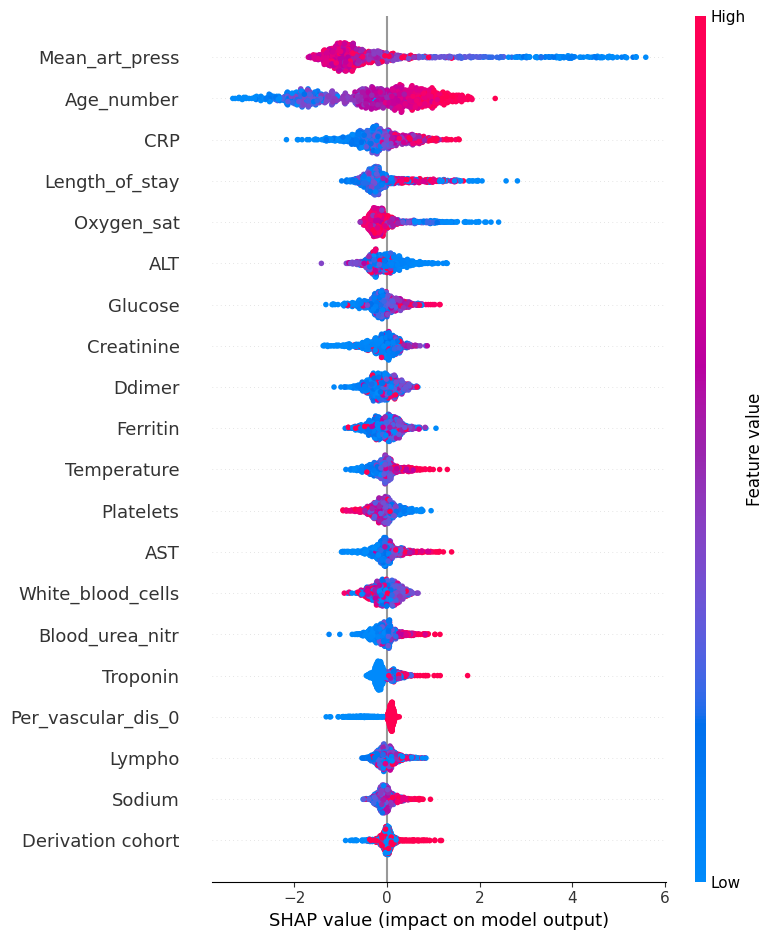

AUROC: 0.8354206243110767


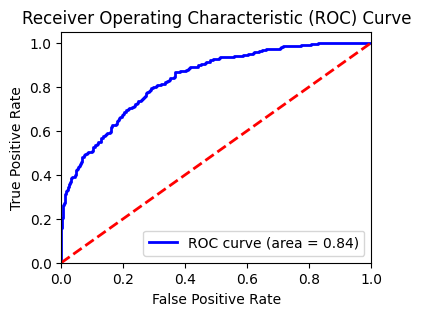

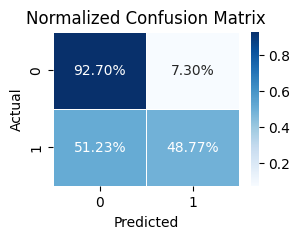

In [40]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Train the XGBoost model
xgb_model.fit(train_x, train_y)

# Predict the probabilities of the positive class (1)
probabilities = xgb_model.predict_proba(test_x)[:, 1]

# Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
threshold = 0.5
predictions = (probabilities > threshold).astype(int)

print(classification_report(test_y, predictions))


accuracy = accuracy_score(test_y, predictions)
print(f"Accuracy on Test set: {accuracy}")
roc_auc = roc_auc_score(test_y, probabilities)
print(f"ROC AUC Score on Test set: {roc_auc}")

# Explain the model's predictions using SHAP values
explainer = shap.Explainer(xgb_model)
shap_values = explainer(test_x)
shap.summary_plot(shap_values, test_x)

auroc = roc_auc_score(test_y, probabilities)
print("AUROC:", auroc)

fpr, tpr, thresholds = roc_curve(test_y, probabilities)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % auroc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# CONFUSION MATRIX
num_classes = 2
cm = confusion_matrix(test_y, predictions)
# Convert confusion matrix to a DataFrame for better visualization
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row
cm_df = pd.DataFrame(cm_percentage, index=range(num_classes), columns=range(num_classes))

# Plot the confusion matrix using seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(cm_df, annot=True, fmt='.2%', cmap='Blues', linewidths=.5)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# LightGBM - najlepší model

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 904, number of negative: 2864
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3865
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239915 -> initscore=-1.153145
[LightGBM] [Info] Start training from score -1.153145
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       699
           1       0.71      0.46      0.56       244

    accuracy                           0.81       943
   macro avg       0.77      0.70      0.72       943
weighted avg       0.80      0.81      0.80       943

Accuracy on Test set: 0.812301166489925

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


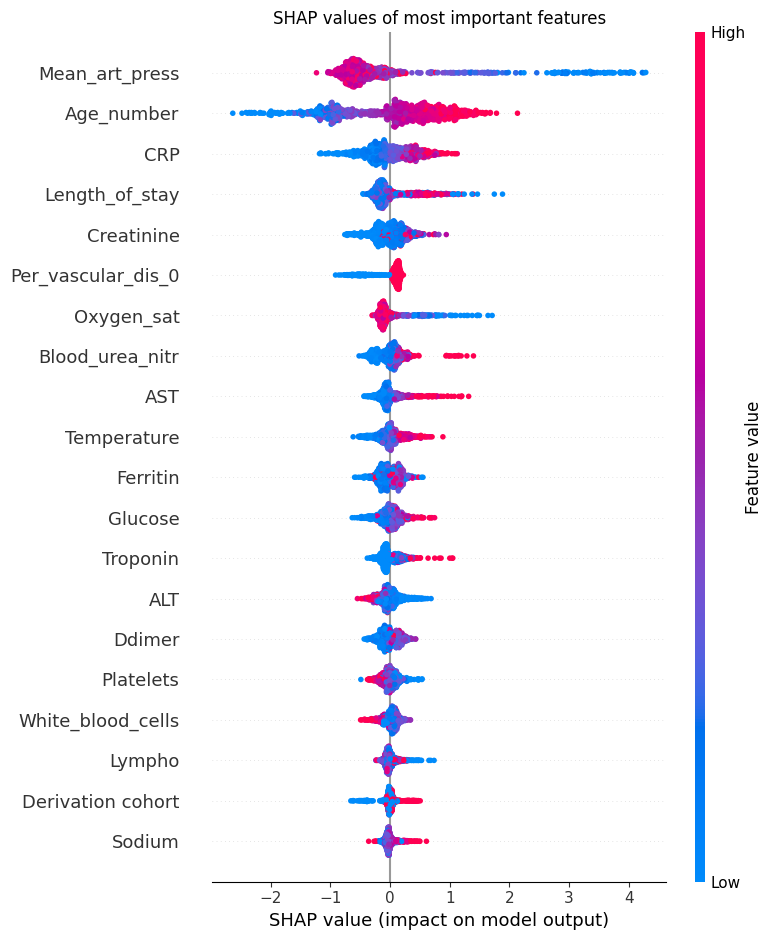

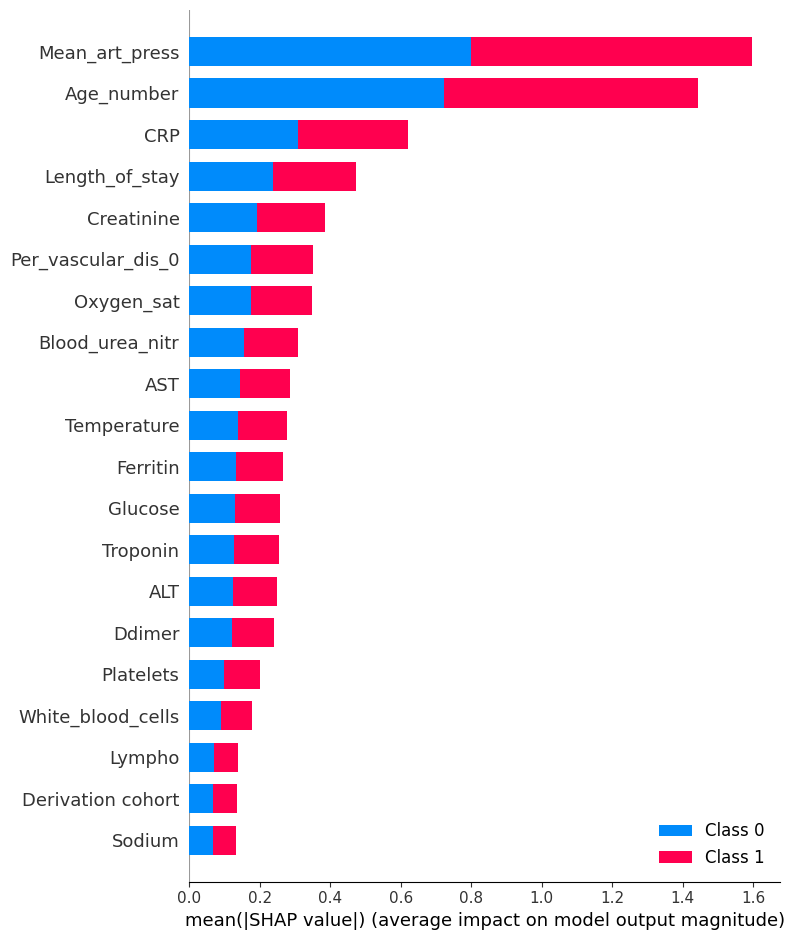

AUROC: 0.8375255048195315


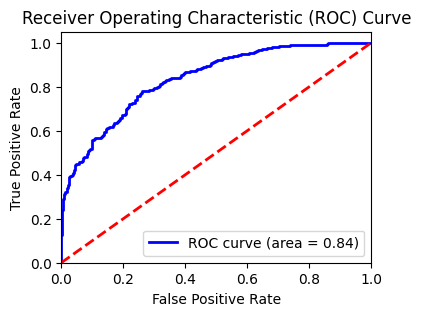

In [41]:
# Initialize the LightGBM model
lgb_model = LGBMClassifier()

# Train the LightGBM model
lgb_model.fit(train_x, train_y)

# Predict the classes on the test set
pred = lgb_model.predict(test_x)

# Predict the probabilities of the positive class for the ROC AUC score calculation
y_prob = lgb_model.predict_proba(test_x)[:, 1]

# Generate a classification report
print(classification_report(test_y, pred))

accuracy = accuracy_score(test_y, pred)
print(f"Accuracy on Test set: {accuracy}")
roc_auc = roc_auc_score(test_y, y_prob)
print(f"ROC AUC Score on Test set: {roc_auc}")

# SHAP PLOT
explainer = shap.TreeExplainer(lgb_model)
# Calculate SHAP values
shap_values = explainer.shap_values(test_x)
# Summary plot for the positive class (index 1)
plt.title("SHAP values of most important features")
shap.summary_plot(shap_values[1], test_x, feature_names=test_x.columns)
# Summary plot with class aggregation (for binary classification, showing the impact for each class)
shap.summary_plot(shap_values, test_x, feature_names=test_x.columns)

# AUCROC Curve
auroc = roc_auc_score(test_y, y_prob)
print("AUROC:", auroc)

# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(test_y, y_prob)

plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % auroc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


# Logistic Regression

In [42]:

# Initialize the Logistic Regression model with balanced class weights
logreg = LogisticRegression(class_weight="balanced", max_iter=1000)
logreg.fit(train_x, train_y)

# Make predictions on the test set
pred = logreg.predict(test_x)

# Predict the probabilities for calculating ROC AUC score
# We need probabilities of the positive class
probabilities = logreg.predict_proba(test_x)[:, 1]

# Generate and print the classification report
# Note: The correct order is first the true labels, followed by the predictions
print(classification_report(test_y, pred))

# Print the accuracy of the Logistic Regression model on the test set
print("Logistic Regression Accuracy on Test set:", accuracy_score(test_y, pred))

# Calculate and print the ROC AUC score
roc_auc = roc_auc_score(test_y, probabilities)
print("ROC AUC Score on Test set:", roc_auc)

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       699
           1       0.51      0.70      0.59       244

    accuracy                           0.75       943
   macro avg       0.69      0.73      0.70       943
weighted avg       0.78      0.75      0.76       943

Logistic Regression Accuracy on Test set: 0.7476139978791092
ROC AUC Score on Test set: 0.8279274842280542


# KNN

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Initialize the KNN model
knn = KNeighborsClassifier()

# Fit the KNN model to the training data
knn.fit(train_x, train_y)

# Make predictions on the test set
pred = knn.predict(test_x)

# Predict the probabilities for calculating ROC AUC score
probabilities = knn.predict_proba(test_x)[:, 1]

print("Classification Report:\n", classification_report(test_y, pred))

print("KNN Accuracy on Test set:", accuracy_score(test_y, pred))

roc_auc = roc_auc_score(test_y, probabilities)
print("ROC AUC Score on Test set:", roc_auc)


Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.92      0.85       699
           1       0.54      0.25      0.35       244

    accuracy                           0.75       943
   macro avg       0.66      0.59      0.60       943
weighted avg       0.72      0.75      0.72       943

KNN Accuracy on Test set: 0.750795334040297
ROC AUC Score on Test set: 0.7007493140083023


# MLP

In [45]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Create a neural network model with increased max_iter
nn_model = MLPClassifier(max_iter=1000)
# Train the neural network model
nn_model.fit(train_x, train_y)

# Make predictions on the test set
predictions = nn_model.predict(test_x)

# Predict the probabilities for calculating ROC AUC score
probabilities = nn_model.predict_proba(test_x)[:, 1]

print(classification_report(test_y, predictions))

accuracy = accuracy_score(test_y, predictions)
print("Multilayer Perceptron Neural Network Accuracy:", accuracy)

roc_auc = roc_auc_score(test_y, probabilities)
print("ROC AUC Score on Test set:", roc_auc)

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       699
           1       0.62      0.50      0.55       244

    accuracy                           0.79       943
   macro avg       0.73      0.70      0.71       943
weighted avg       0.78      0.79      0.78       943

Multilayer Perceptron Neural Network Accuracy: 0.792152704135737
ROC AUC Score on Test set: 0.7991275592767185


# SHOW top features
Aggregate SHAP values for all 3 classes and select top features


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


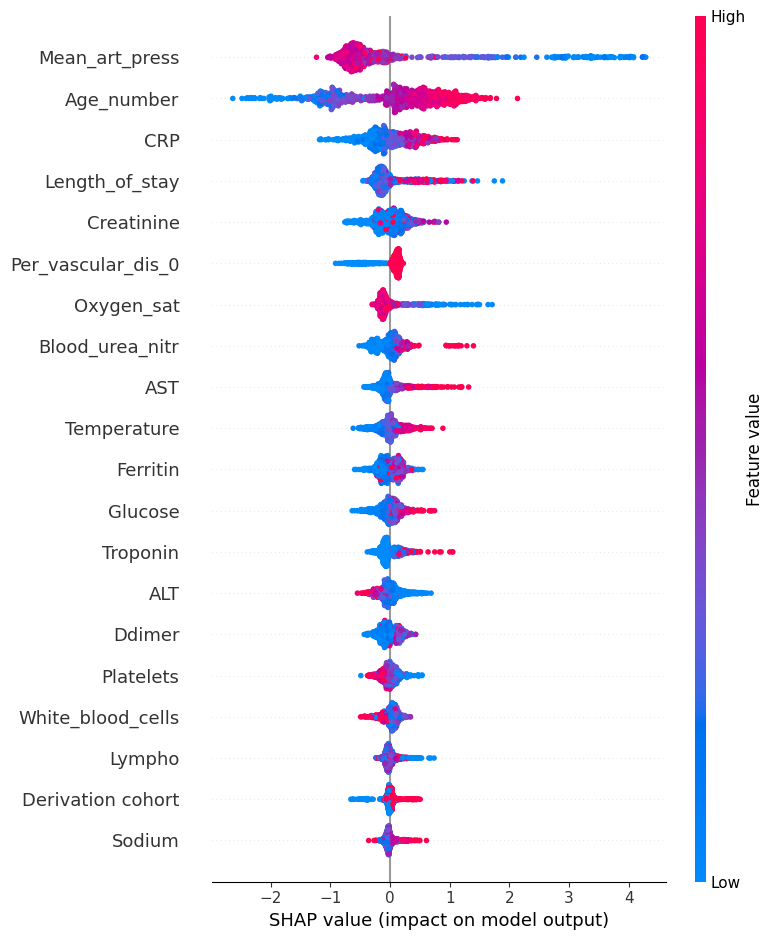

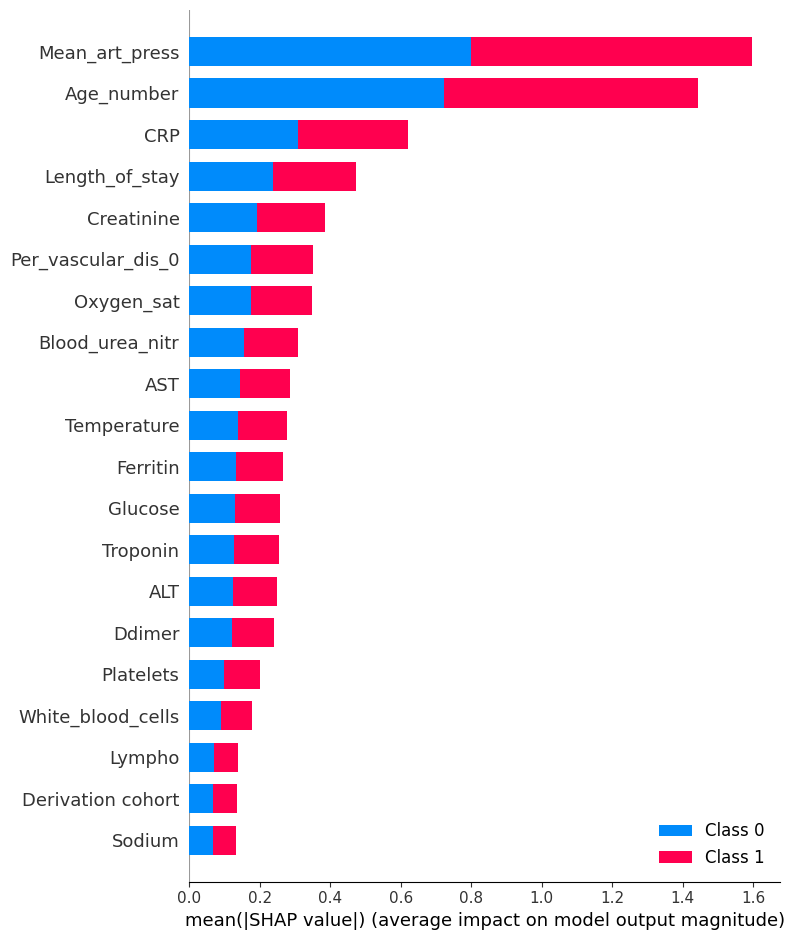

Top 10 Features DataFrame:
                Feature  Mean SHAP Value
24      Mean_art_press         0.798034
21          Age_number         0.721962
37                 CRP         0.309841
1       Length_of_stay         0.236315
29          Creatinine         0.192126
49  Per_vascular_dis_0         0.175091
22          Oxygen_sat         0.174175
28     Blood_urea_nitr         0.154885
32                 AST         0.143310
23         Temperature         0.138749
36            Ferritin         0.132859
31             Glucose         0.128496
38            Troponin         0.127891
33                 ALT         0.124108
25              Ddimer         0.120329
26           Platelets         0.099763

Top 10 Features List:
 ['Mean_art_press', 'Age_number', 'CRP', 'Length_of_stay', 'Creatinine', 'Per_vascular_dis_0', 'Oxygen_sat', 'Blood_urea_nitr', 'AST', 'Temperature', 'Ferritin', 'Glucose', 'Troponin', 'ALT', 'Ddimer', 'Platelets']


In [46]:
# SHAP PLOT
explainer = shap.TreeExplainer(lgb_model)
# Calculate SHAP values
shap_values = explainer.shap_values(test_x)
# Summary plot for the positive class (index 1)
shap.summary_plot(shap_values[1], test_x, feature_names=test_x.columns)
# Summary plot with class aggregation (for binary classification, showing the impact for each class)
shap.summary_plot(shap_values, test_x, feature_names=test_x.columns)

# Calculate the mean absolute SHAP value for each feature across all classes
shap_values_aggregated = np.abs(shap_values).mean(axis=0)  # This is correct for multi-output models

# If shap_values is a list of matrices (one per class), we first concatenate them along the feature axis
if isinstance(shap_values, list):
    shap_values_aggregated = np.concatenate([np.abs(sv) for sv in shap_values], axis=0).mean(axis=0)

# Get feature names from the dataset
feature_names = test_x.columns

# Create a DataFrame of features and their corresponding mean absolute SHAP values
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean SHAP Value': shap_values_aggregated
}).sort_values(by='Mean SHAP Value', ascending=False)

# Extract the top 10 features
top_10_features_df = feature_importance_df.head(16)
top_10_features_list = top_10_features_df['Feature'].tolist()

print("Top 10 Features DataFrame:\n", top_10_features_df)
print("\nTop 10 Features List:\n", top_10_features_list)

## SELECT TOP FEATURES

In [47]:
top_features_list = ['Mean_art_press', 'Age_number', 'CRP', 'Length_of_stay','Creatinine', 'Oxygen_sat', 'Blood_urea_nitr', 'AST', 'Temperature', 'Ferritin', 'Glucose', 'Troponin', 'ALT', 'Ddimer', 'Platelets']

In [48]:
X = data[top_features_list]
y = data["Death"]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4711 entries, 0 to 4710
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Mean_art_press   4711 non-null   float64
 1   Age_number       4711 non-null   float64
 2   CRP              4711 non-null   float64
 3   Length_of_stay   4711 non-null   float64
 4   Creatinine       4711 non-null   float64
 5   Oxygen_sat       4711 non-null   float64
 6   Blood_urea_nitr  4711 non-null   float64
 7   AST              4711 non-null   float64
 8   Temperature      4711 non-null   float64
 9   Ferritin         4711 non-null   float64
 10  Glucose          4711 non-null   float64
 11  Troponin         4711 non-null   float64
 12  ALT              4711 non-null   float64
 13  Ddimer           4711 non-null   float64
 14  Platelets        4711 non-null   float64
dtypes: float64(15)
memory usage: 552.2 KB


In [ ]:
from sklearn.model_selection import train_test_split

# First, split the data into a temporary training set and a final test set (80% train + val, 20% test)
X_train_val, test_x, y_train_val, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

# Now, split the temporary training set into final training and validation sets (87.5% train, 12.5% val of 80% train+val set)
# This results in roughly 70% train, 20% test, and 10% val of the original dataset
train_x, val_x, train_y, val_y = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42)

print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)
print("val_x :",val_x.shape)
print("val_y :",val_y.shape)

Train_x : (3297, 15)
Test_x : (943, 15)
Train_y : (3297,)
Test_y : (943,)
val_x : (471, 15)
val_y : (471,)


In [49]:
from sklearn.model_selection import train_test_split
train_x, test_x, train_y, test_y = train_test_split(X,y, test_size=0.2, random_state=42)
print("Train_x :",train_x.shape)
print("Test_x :",test_x.shape)
print("Train_y :",train_y.shape)
print("Test_y :",test_y.shape)

Train_x : (3768, 15)
Test_x : (943, 15)
Train_y : (3768,)
Test_y : (943,)


## LightGBM with most important features

### Základný model LGBM

In [50]:
# Initialize the LightGBM model
lgb_model = LGBMClassifier()

# Train the LightGBM model
lgb_model.fit(train_x, train_y)

# Predict the classes on the test set
pred = lgb_model.predict(test_x)

# Predict the probabilities of the positive class for the ROC AUC score calculation
y_prob = lgb_model.predict_proba(test_x)[:, 1]

# Generate a classification report
print(classification_report(test_y, pred))

accuracy = accuracy_score(test_y, pred)
print(f"Accuracy on Test set: {accuracy}")

# Calculate and print the ROC AUC score
roc_auc = roc_auc_score(test_y, y_prob)
print(f"ROC AUC Score on Test set: {roc_auc}")

[LightGBM] [Info] Number of positive: 904, number of negative: 2864
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3108
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239915 -> initscore=-1.153145
[LightGBM] [Info] Start training from score -1.153145
              precision    recall  f1-score   support

           0       0.84      0.94      0.88       699
           1       0.72      0.48      0.57       244

    accuracy                           0.82       943
   macro avg       0.78      0.71      0.73       943
weighted avg       0.81      0.82      0.80       943

Accuracy on Test set: 0.8176033934252386
ROC AUC Score on Test set: 0.8343183470531673


[LightGBM] [Info] Number of positive: 904, number of negative: 2864
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000574 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3108
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239915 -> initscore=-1.153145
[LightGBM] [Info] Start training from score -1.153145
              precision    recall  f1-score   support

           0       0.84      0.94      0.88       699
           1       0.72      0.48      0.57       244

    accuracy                           0.82       943
   macro avg       0.78      0.71      0.73       943
weighted avg       0.81      0.82      0.80       943

Accuracy on Test set: 0.8176033934252386
ROC AUC Score on Test set: 0.8343183470531673


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


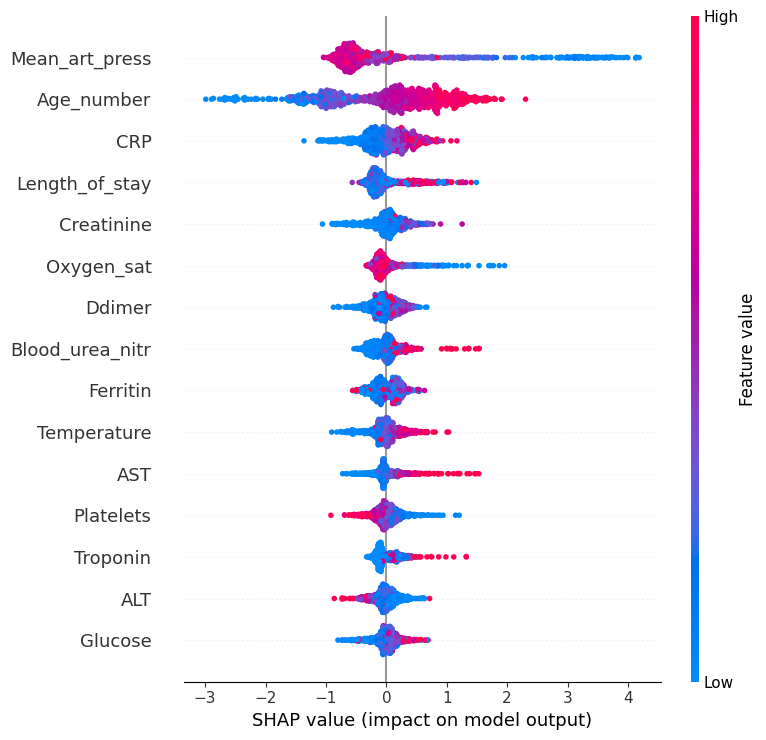

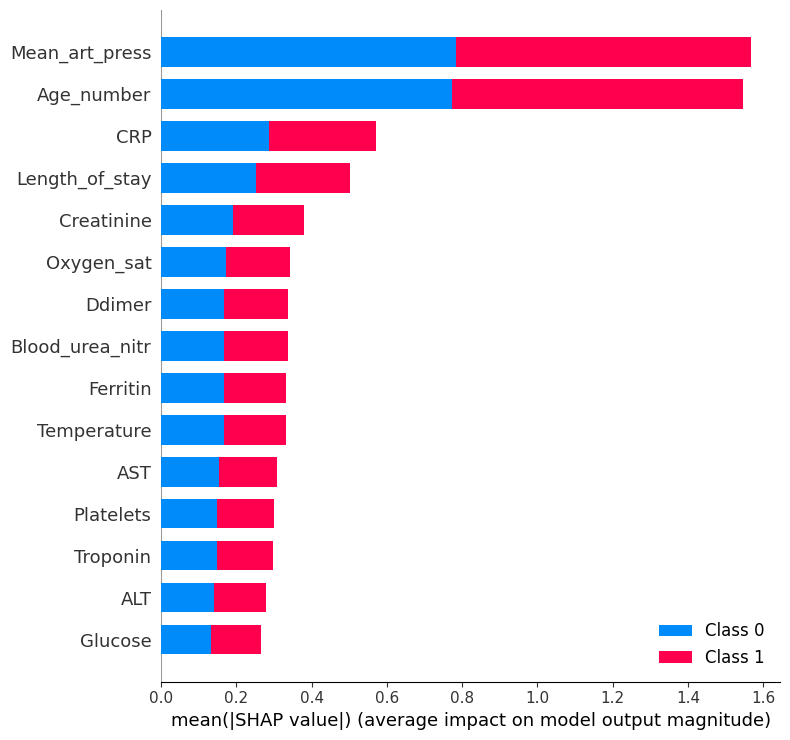

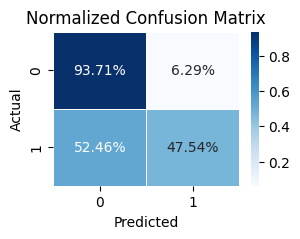

In [51]:

lgb_model = LGBMClassifier()

# Train the LightGBM model
lgb_model.fit(train_x, train_y)

# Predict the classes on the test set
pred = lgb_model.predict(test_x)

# Predict the probabilities of the positive class for the ROC AUC score calculation
y_prob = lgb_model.predict_proba(test_x)[:, 1]

# Generate a classification report
print(classification_report(test_y, pred))

accuracy = accuracy_score(test_y, pred)
print(f"Accuracy on Test set: {accuracy}")

roc_auc = roc_auc_score(test_y, y_prob)
print(f"ROC AUC Score on Test set: {roc_auc}")

# Initialize SHAP explainer
explainer = shap.TreeExplainer(lgb_model)
# Calculate SHAP values
shap_values = explainer.shap_values(test_x)
# Summary plot for the positive class (index 1)
shap.summary_plot(shap_values[1], test_x, feature_names=test_x.columns)
# Summary plot with class aggregation (for binary classification, showing the impact for each class)
shap.summary_plot(shap_values, test_x, feature_names=test_x.columns)

num_classes = 2
cm = confusion_matrix(test_y, pred)
# Convert confusion matrix to a DataFrame for better visualization
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row
cm_df = pd.DataFrame(cm_percentage, index=range(num_classes), columns=range(num_classes))

# Plot the confusion matrix using seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(cm_df, annot=True, fmt='.2%', cmap='Blues', linewidths=.5)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Step 2 - NAJLEPŠÍ MODEL

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Info] Number of positive: 904, number of negative: 2864
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000577 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3108
[LightGBM] [Info] Number of data points in the train set: 3768, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.386986 -> initscore=-0.459998
[LightGBM] [Info] Start training from score -0.459998
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
              precisio

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


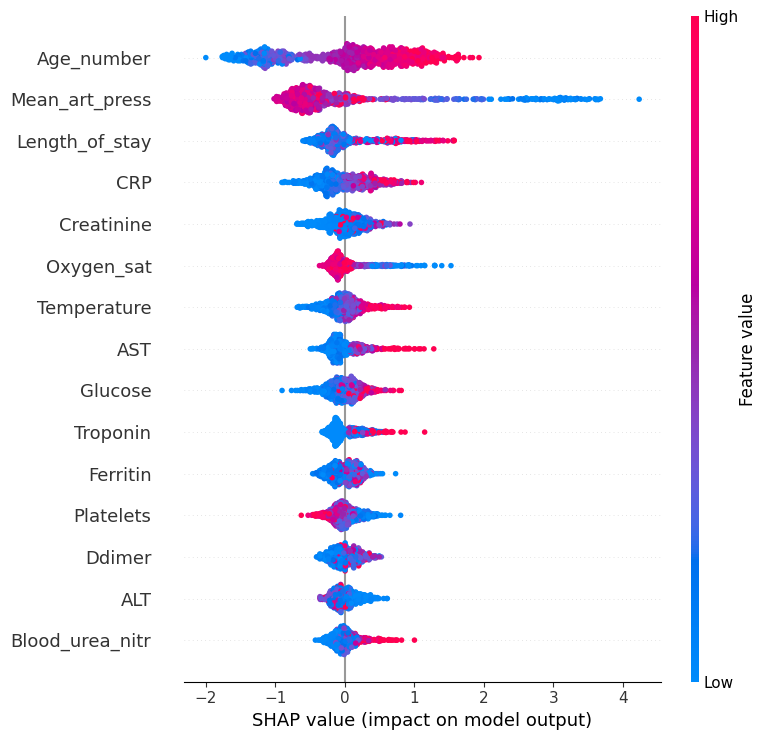

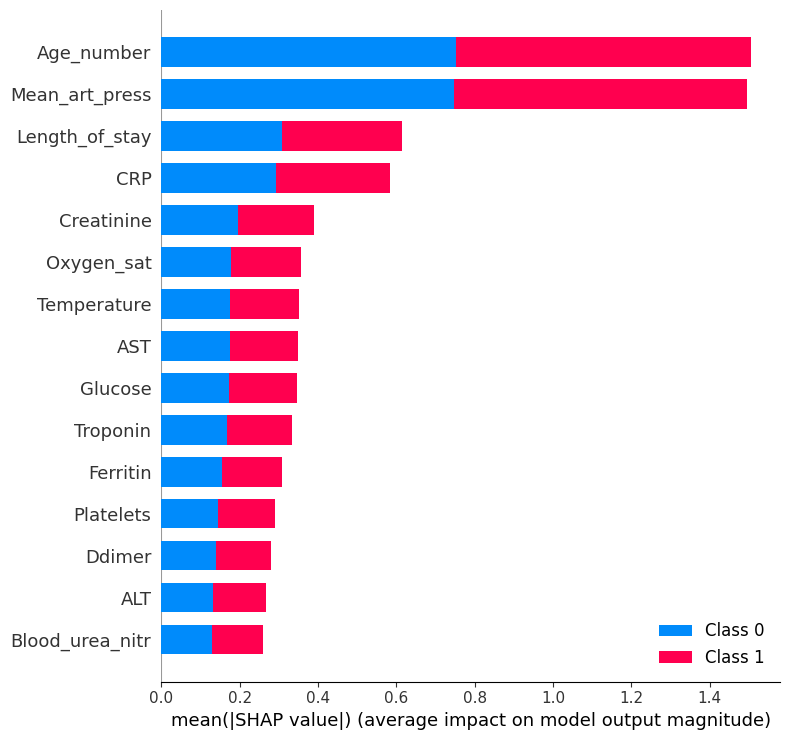

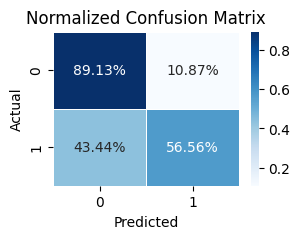

In [52]:
# Initialize the LightGBM model
lgb_model = LGBMClassifier(class_weight={0: 1, 1: 2},reg_alpha= 2, reg_lambda= 1, min_data_in_leaf=50) # 'reg_alpha= 1, reg_lambda= 1, min_data_in_leaf=80, num_leaves= 50

# Train the LightGBM model
lgb_model.fit(train_x, train_y)

# Predict the classes on the test set
pred = lgb_model.predict(test_x)

# Predict the probabilities of the positive class for the ROC AUC score calculation
y_prob = lgb_model.predict_proba(test_x)[:, 1]


# Generate a classification report
print(classification_report(test_y, pred))

accuracy = accuracy_score(test_y, pred)
print(f"Accuracy on Test set: {accuracy}")

# Calculate and print the ROC AUC score
roc_auc = roc_auc_score(test_y, y_prob)
print(f"ROC AUC Score on Test set: {roc_auc}")


# Initialize SHAP explainer
explainer = shap.TreeExplainer(lgb_model)
# Calculate SHAP values
shap_values = explainer.shap_values(test_x)
# Summary plot for the positive class (index 1)
shap.summary_plot(shap_values[1], test_x, feature_names=test_x.columns)
# Summary plot with class aggregation (for binary classification, showing the impact for each class)
shap.summary_plot(shap_values, test_x, feature_names=test_x.columns)

num_classes = 2
cm = confusion_matrix(test_y, pred)
# Convert confusion matrix to a DataFrame for better visualization
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row
cm_df = pd.DataFrame(cm_percentage, index=range(num_classes), columns=range(num_classes))

# Plot the confusion matrix using seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(cm_df, annot=True, fmt='.2%', cmap='Blues', linewidths=.5)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Fit and save same scaler scaler, but fitted only on the new features

In [53]:
import joblib

# Select the columns we want to normalize
columns_to_normalize = top_features_list

# Create a new DataFrame for the columns to normalize
data_to_normalize = original_data[columns_to_normalize]

columns_order = ['Mean_art_press', 'Age_number', 'CRP', 'Length_of_stay','Creatinine', 'Oxygen_sat', 'Blood_urea_nitr', 'AST', 'Temperature', 'Ferritin', 'Glucose', 'Troponin', 'ALT', 'Ddimer', 'Platelets']

# Reorder the DataFrame columns
data_to_normalize = data_to_normalize[columns_order]


scaler = MinMaxScaler()
scaler.fit(data_to_normalize)


# Save the scaler
joblib.dump(scaler, 'scaler_death.pkl')

['scaler_death.pkl']

## Uložiť najlepší model ako .pkl

In [54]:
import joblib

# Save the trained model to a file using joblib
joblib.dump(lgb_model, 'lgb_death.pkl')

['lgb_death.pkl']

# Testovanie na novom datasete UNLP - na základe rozhodnutia etickej komisie tieto údaje nemožno poskytnúť v prílohách práce

### Príprava dát z UNLP

In [55]:
data_unlp = pd.read_excel("UNLP_data.xlsx")
data_unlp.head()

,Age_number,Oxygen_sat,CRP,AST,Ddimer,Inter_norm_ratio,Creatinine,Platelets,Mean_art_press,Blood_urea_nitr,Ferritin,Troponin,Temperature,ALT,Glucose,Length_of_stay,Death
0,63,0.63,152.72,111.6,6.124,1.34,1.07350,463,120.000000,18.515406,1134.6,0.146,37.0,43.2,102.70,4,1
1,62,0.70,71.23,411.0,1.475,1.28,3.73239,324,72.000000,70.840336,57.0,0.182,36.6,492.0,122.52,0,1
2,90,0.98,70.70,29.4,0.934,1.52,1.24978,279,100.000000,33.949580,53.3,0.071,37.6,22.8,99.10,15,1
3,76,0.91,50.78,66.6,0.514,1.08,1.49838,230,90.000000,38.123249,1077.8,0.078,36.9,44.4,254.06,11,1
4,83,0.90,118.64,48.6,0.739,1.49,0.87688,157,106.666667,17.254902,253.9,0.023,38.0,21.6,133.33,3,1


In [56]:
# Multiply entire column by 100
data_unlp['Oxygen_sat'] = data_unlp['Oxygen_sat'] * 100

data_unlp.head()

,Age_number,Oxygen_sat,CRP,AST,Ddimer,Inter_norm_ratio,Creatinine,Platelets,Mean_art_press,Blood_urea_nitr,Ferritin,Troponin,Temperature,ALT,Glucose,Length_of_stay,Death
0,63,63.0,152.72,111.6,6.124,1.34,1.07350,463,120.000000,18.515406,1134.6,0.146,37.0,43.2,102.70,4,1
1,62,70.0,71.23,411.0,1.475,1.28,3.73239,324,72.000000,70.840336,57.0,0.182,36.6,492.0,122.52,0,1
2,90,98.0,70.70,29.4,0.934,1.52,1.24978,279,100.000000,33.949580,53.3,0.071,37.6,22.8,99.10,15,1
3,76,91.0,50.78,66.6,0.514,1.08,1.49838,230,90.000000,38.123249,1077.8,0.078,36.9,44.4,254.06,11,1
4,83,90.0,118.64,48.6,0.739,1.49,0.87688,157,106.666667,17.254902,253.9,0.023,38.0,21.6,133.33,3,1


In [57]:
# Select the columns we want to normalize
columns_to_normalize = top_features_list

# Create a new DataFrame for the columns to normalize from the new dataset
data_to_normalize = data_unlp[columns_to_normalize]

# Reorder the DataFrame columns to match the order used during scaler fitting
columns_order = ['Mean_art_press', 'Age_number', 'CRP', 'Length_of_stay', 'Creatinine', 'Oxygen_sat', 'Blood_urea_nitr', 'AST', 'Temperature', 'Ferritin', 'Glucose', 'Troponin', 'ALT', 'Ddimer', 'Platelets']
data_to_normalize = data_to_normalize[columns_order]

# Normalize the new data using the previously fitted scaler
normalized_data = scaler.transform(data_to_normalize)

# Optionally, convert back to DataFrame for readability or further processing
normalized_data_df = pd.DataFrame(normalized_data, columns=columns_order)


In [58]:
test_x_unlp = normalized_data_df
test_y_unlp = data_unlp["Death"]

In [59]:
test_x_unlp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Mean_art_press   45 non-null     float64
 1   Age_number       45 non-null     float64
 2   CRP              45 non-null     float64
 3   Length_of_stay   45 non-null     float64
 4   Creatinine       45 non-null     float64
 5   Oxygen_sat       45 non-null     float64
 6   Blood_urea_nitr  45 non-null     float64
 7   AST              45 non-null     float64
 8   Temperature      45 non-null     float64
 9   Ferritin         45 non-null     float64
 10  Glucose          45 non-null     float64
 11  Troponin         45 non-null     float64
 12  ALT              45 non-null     float64
 13  Ddimer           45 non-null     float64
 14  Platelets        45 non-null     float64
dtypes: float64(15)
memory usage: 5.4 KB


In [60]:
print(test_x.shape)
print(test_y.shape)

(943, 15)
(943,)


## LightGBM na novych pacientoch z UNLP

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
              precision    recall  f1-score   support

           0       0.67      0.91      0.77        22
           1       0.87      0.57      0.68        23

    accuracy                           0.73        45
   macro avg       0.77      0.74      0.73        45
weighted avg       0.77      0.73      0.73        45

Accuracy on Test set: 0.7333333333333333
ROC AUC Score on Test set: 0.8359683794466404


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


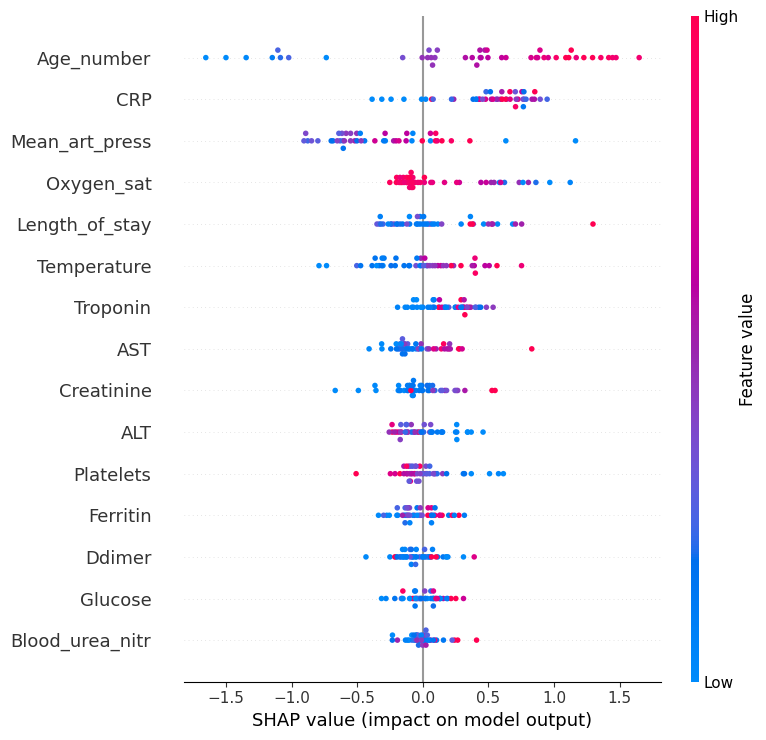

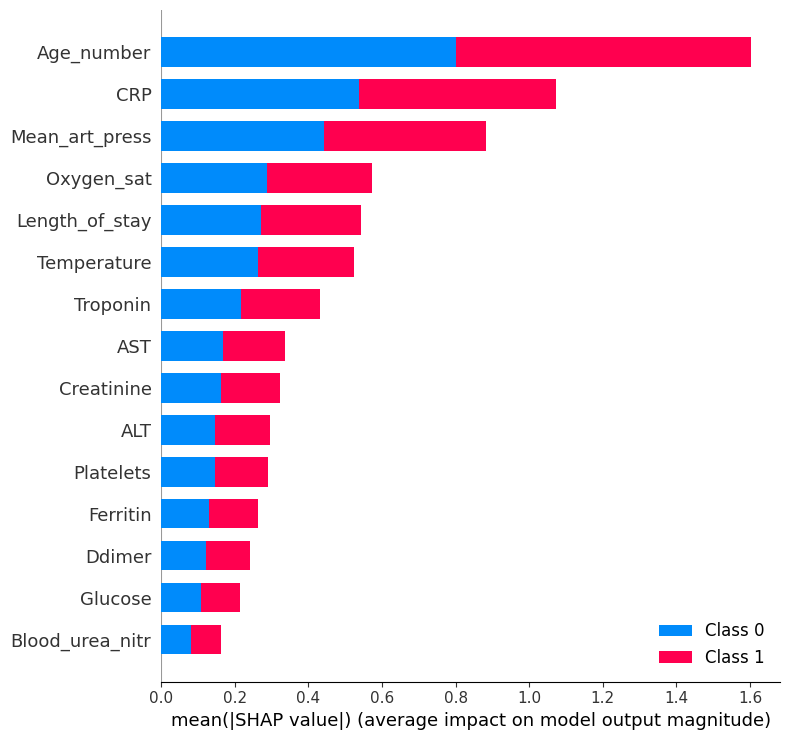

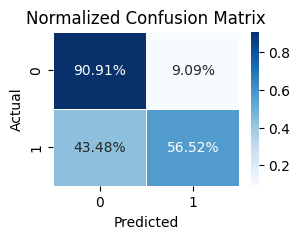

In [61]:
# Predict the classes on the test set
pred = lgb_model.predict(test_x_unlp)

# Predict the probabilities of the positive class for the ROC AUC score calculation
y_prob = lgb_model.predict_proba(test_x_unlp)[:, 1]


# Generate a classification report
print(classification_report(test_y_unlp, pred))

accuracy = accuracy_score(test_y_unlp, pred)
print(f"Accuracy on Test set: {accuracy}")

# Calculate and print the ROC AUC score
roc_auc = roc_auc_score(test_y_unlp, y_prob)
print(f"ROC AUC Score on Test set: {roc_auc}")

# Initialize SHAP explainer
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(test_x_unlp)
shap.summary_plot(shap_values[1], test_x_unlp, feature_names=test_x.columns)
shap.summary_plot(shap_values, test_x_unlp, feature_names=test_x.columns)

# CONFUSION MATRIX
num_classes = 2
cm = confusion_matrix(test_y_unlp, pred)
# Convert confusion matrix to a DataFrame for better visualization
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize by row
cm_df = pd.DataFrame(cm_percentage, index=range(num_classes), columns=range(num_classes))

# Plot the confusion matrix using seaborn
plt.figure(figsize=(3, 2))
sns.heatmap(cm_df, annot=True, fmt='.2%', cmap='Blues', linewidths=.5)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()